# PFM: Machine Learning - Módulo de Fidelización y Recompra
## Fase 2: Modelado Predictivo y Visión de Negocio

**Contexto del Documento:** Este notebook abarca la fase final y decisiva del proyecto. Partiendo de los datos depurados en la Fase 1, el objetivo técnico es entrenar y optimizar un modelo de Machine Learning capaz de predecir la probabilidad de recompra de nuestra base de clientes. 

Sin embargo, el Machine Learning debe estar siempre subordinado a la estrategia empresarial. Por directriz del proyecto, antes de iniciar la fase de modelado puro, realizaremos un diagnóstico visual para el equipo directivo respondiendo a tres preguntas críticas: *¿Cómo evoluciona estacionalmente el negocio? ¿Cómo se distribuye el valor entre los clientes? ¿Cuáles son los productos tractores?*

## 1. Ingesta de Datos: Arquitectura de Doble Enfoque

Para mantener la eficiencia computacional (evitando cargar el Excel crudo original) y satisfacer tanto las necesidades de Negocio como los requisitos matemáticos del Algoritmo, implementamos una ingesta basada en dos fuentes optimizadas en formato columnar (`.parquet`):

1. **Dataset Transaccional / Storytelling (`df_transactions`):** Conserva la granularidad original a nivel de ticket y fecha exacta. Se utilizará exclusivamente en el primer bloque para la extracción de *Insights* comerciales.
2. **Dataset de Modelado (`df_model`):** La matriz analítica maestra (1 fila = 1 cliente), previamente segmentada mediante una fecha de corte temporal estricta para evitar la fuga de datos (*Data Leakage*). Es el conjunto de datos que alimentará la tubería de Machine Learning.


In [39]:
# Importación de librerías base

import pandas as pd
import numpy as np
import seaborn as sns
import scipy
if not hasattr(scipy, 'interp'):
    scipy.interp = np.interp
import scikitplot as skplt
from xgboost import XGBClassifier
import time
import shap
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from IPython.display import display
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV 
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, auc

print("   fase 2: ingesta de datos (arquitectura dual)   ")


# 1. Definición estricta de rutas relativas
DATA_DIR = r"../data/processed"
PATH_TRANS = os.path.join(DATA_DIR, "df_transactions.parquet")
PATH_MODEL = os.path.join(DATA_DIR, "df_model.parquet")

try:
    # 2. Carga del dataset transaccional (Para Storytelling y Negocio)
    df_transactions = pd.read_parquet(PATH_TRANS)
    print("EXITO: Dataset transaccional (Storytelling) cargado correctamente.")
    print(f" -> Dimensiones: {df_transactions.shape[0]:,} filas y {df_transactions.shape[1]} columnas.\n")
    
    # 3. Carga de la matriz predictiva (Para Machine Learning)
    df_model = pd.read_parquet(PATH_MODEL)
    print("EXITO: Matriz predictiva (Machine Learning) cargada correctamente.")
    print(f" -> Dimensiones: {df_model.shape[0]:,} filas y {df_model.shape[1]} columnas.\n")
    
    # 4. Verificación visual del dataset maestro
    print("Muestra de la matriz de modelado (primeras 3 filas):")
    display(df_model.head(3))

except Exception as e:
    print("ERROR FATAL: No se han podido cargar los archivos.")
    print(f"Detalle técnico: {e}")
    print("Verifica que la carpeta '../data/processed' existe respecto a la ubicación de este notebook.")


   fase 2: ingesta de datos (arquitectura dual)   
EXITO: Dataset transaccional (Storytelling) cargado correctamente.
 -> Dimensiones: 779,425 filas y 8 columnas.

EXITO: Matriz predictiva (Machine Learning) cargada correctamente.
 -> Dimensiones: 4,967 filas y 23 columnas.

Muestra de la matriz de modelado (primeras 3 filas):


,Customer ID,Target,Recency,Frequency,Monetary,return_rate,has_returns,Cat_Bag_Storage,Cat_Kitchen_Baking,Cat_Home_Decor,...,Cat_Christmas,Cat_Niche_Kids_Alt,Total_Quantity,Unique_Products,Average_Order_Value,Tenure,Inter_purchase_Time,Momentum,Is_UK,Recency_Tenure_Ratio
0,13085,1,111,7,2295.30,0.222222,1,1,1,1,...,1,1,900,46,327.900000,555,79.285714,-1739.10,1,0.199640
1,13078,1,17,41,20857.28,0.414286,1,1,1,1,...,1,1,7842,131,508.714146,555,13.536585,-1907.00,1,0.030576
2,15362,0,265,2,613.08,0.000000,0,1,1,1,...,1,1,368,38,306.540000,555,277.500000,-8.42,1,0.476619


## 2. Business Storytelling: Diagnóstico del Negocio

Antes de modelar el comportamiento individual de cada cliente, es imperativo comprender la dinámica macro de la empresa. El Machine Learning aportará valor estratégico solo si se alinea con la realidad del negocio.

### 2.1. Evolución Temporal y Estacionalidad

Analizaremos el histórico completo de los 24 meses de transacciones para identificar patrones estacionales, picos de demanda y la correlación entre el volumen de pedidos (tickets) y los ingresos generados. Esta visión nos permitirá entender en qué momentos del año el riesgo de fuga (*churn*) o la oportunidad de recompra son más críticos.


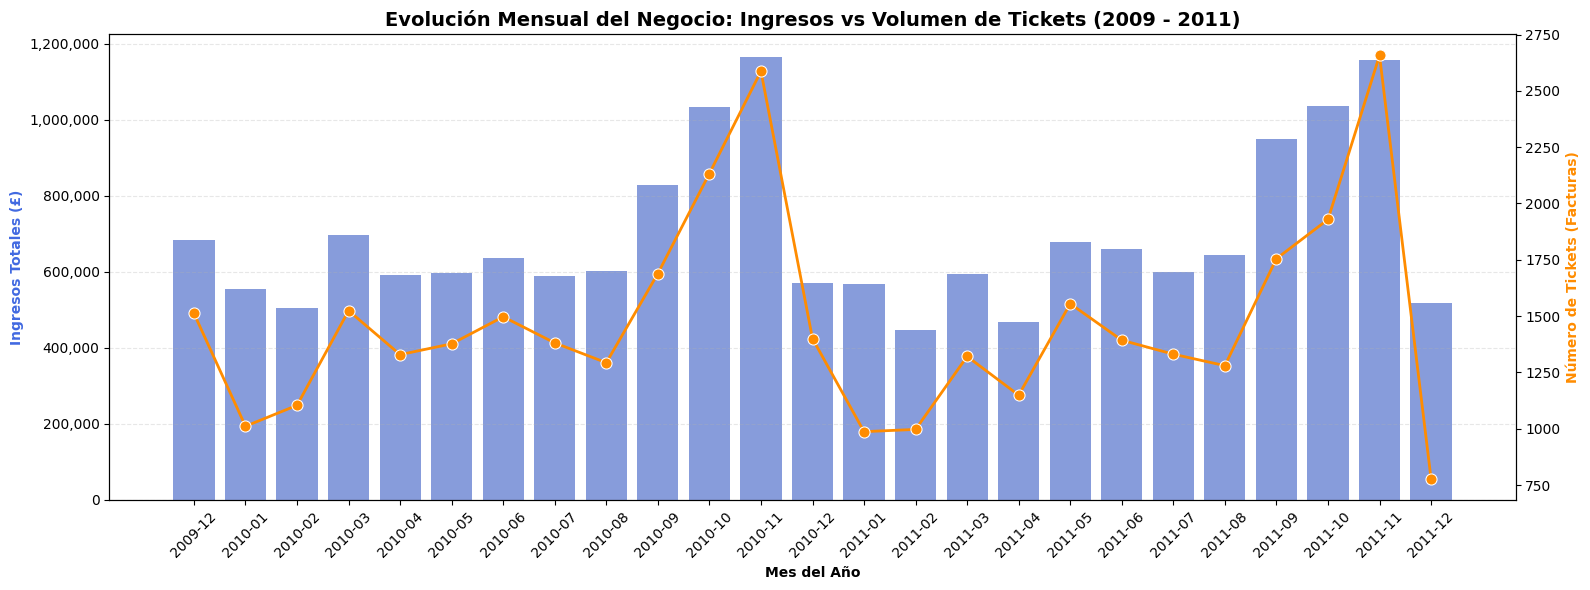

In [40]:
# 1. Preparación de los datos temporales y financieros
# Aseguramos que la fecha sea datetime y calculamos el Ingreso (Revenue) por línea
df_transactions['InvoiceDate'] = pd.to_datetime(df_transactions['InvoiceDate'])
df_transactions['Revenue'] = df_transactions['Quantity'] * df_transactions['Price']

# Extraemos el Año y Mes para la agrupación temporal
df_transactions['YearMonth'] = df_transactions['InvoiceDate'].dt.to_period('M').astype(str)

# 2. Agrupación macro del negocio
# Calculamos Ingresos Totales y recuento de Facturas Únicas (Tickets) por mes
monthly_sales = df_transactions.groupby('YearMonth').agg(
    Total_Revenue=('Revenue', 'sum'),
    Total_Tickets=('Invoice', 'nunique')
).reset_index()

# 3. Visualización Ejecutiva (Doble Eje)
fig, ax1 = plt.subplots(figsize=(16, 6))

# Eje Principal (Izquierdo): Ingresos en gráfico de barras
sns.barplot(data=monthly_sales, x='YearMonth', y='Total_Revenue', color='royalblue', ax=ax1, alpha=0.7)
ax1.set_ylabel('Ingresos Totales (£)', color='royalblue', fontweight='bold')
ax1.set_xlabel('Mes del Año', fontweight='bold')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', linestyle='--', alpha=0.3)

# Formatear el eje Y principal para que muestre millones/miles legibles
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

# Eje Secundario (Derecho): Volumen de Tickets en gráfico de líneas
ax2 = ax1.twinx()
sns.lineplot(data=monthly_sales, x='YearMonth', y='Total_Tickets', color='darkorange', marker='o', ax=ax2, linewidth=2, markersize=8)
ax2.set_ylabel('Número de Tickets (Facturas)', color='darkorange', fontweight='bold')

# Formato final
plt.title('Evolución Mensual del Negocio: Ingresos vs Volumen de Tickets (2009 - 2011)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Interpretación de Negocio: Estacionalidad y Truncamiento

El análisis visual de la serie temporal revela tres hallazgos críticos para la planificación estratégica y presupuestaria del equipo de marketing:

1. **El "Efecto Q4" (Dependencia de la Campaña de Navidad):** Se observa un pico de demanda masivo y desproporcionado durante los meses de octubre, noviembre y diciembre. Esto indica que el negocio tiene una estacionalidad extrema. La implicación de negocio es clara: perder a un cliente recurrente justo antes de este trimestre tiene un coste de oportunidad devastador (*Customer Lifetime Value*). 
2. **El Repunte de Primavera (Marzo):** Existe un segundo pico, de menor magnitud pero consistente, durante el mes de marzo. En el mercado británico, esto suele correlacionar fuertemente con las campañas del Día de la Madre y la anticipación de la Pascua, lo que marca el segundo momento más importante del año para la activación de clientes dormidos.
3. **Alerta Analítica (El falso desplome del último mes):** Se observa una caída abrupta de los ingresos y tickets en el último mes de la serie (Junio de 2011). Es crucial aclarar a Negocio que esto **no es una crisis de ventas real**, sino un artefacto de nuestra arquitectura de datos: representa nuestra "Fecha de Corte" (*Cutoff Date*). El mes de junio solo contiene transacciones hasta el día 9 (momento en el que separamos el pasado del futuro para entrenar el algoritmo de Machine Learning).


### 2.2. Concentración del Valor y Riesgo: Análisis de Pareto

No todos los clientes tienen el mismo impacto en la cuenta de resultados. Para justificar el Retorno de Inversión (ROI) de un modelo predictivo de fuga, es necesario diagnosticar cómo se distribuye la facturación entre la base de usuarios. 

Aplicaremos un análisis basado en el Principio de Pareto (Curva de Lorenz) sobre la variable `Monetary`. El objetivo es identificar qué porcentaje exacto de nuestra base de clientes sostiene la inmensa mayoría de los ingresos, definiendo así el segmento crítico que nuestro sistema de Machine Learning deberá proteger con mayor prioridad.


Calculando concentración de la facturación     
Resultado analítico: El 30.20% de los clientes genera el 80% de los ingresos.


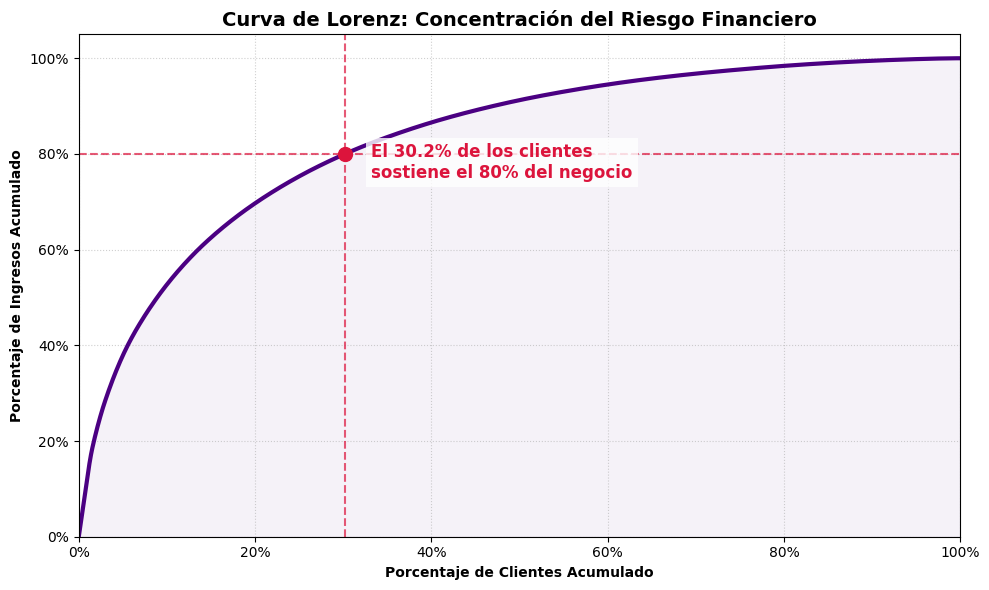

In [41]:
print("Calculando concentración de la facturación     ")


# 1. Preparación matemática de Pareto
# Ordenamos los clientes por su valor monetario (de mayor a menor)
df_pareto = df_model.sort_values(by='Monetary', ascending=False).reset_index(drop=True)

# Calculamos el porcentaje acumulado de clientes (Eje X)
df_pareto['Customer_Percentage'] = (df_pareto.index + 1) / len(df_pareto) * 100

# Calculamos el porcentaje acumulado de ingresos (Eje Y)
total_revenue = df_pareto['Monetary'].sum()
df_pareto['Cumulative_Revenue_Percentage'] = (df_pareto['Monetary'].cumsum() / total_revenue) * 100

# 2. Identificación del punto de corte crítico (Umbral del 80% de ingresos)
punto_80_revenue = df_pareto[df_pareto['Cumulative_Revenue_Percentage'] >= 80].iloc[0]
porcentaje_clientes_80 = punto_80_revenue['Customer_Percentage']

print(f"Resultado analítico: El {porcentaje_clientes_80:.2f}% de los clientes genera el 80% de los ingresos.")

# 3. Visualización Ejecutiva (Curva de Lorenz)
fig, ax = plt.subplots(figsize=(10, 6))

# Dibujamos la curva principal y sombreamos el área bajo la curva
ax.plot(df_pareto['Customer_Percentage'], df_pareto['Cumulative_Revenue_Percentage'], color='indigo', linewidth=3)
ax.fill_between(df_pareto['Customer_Percentage'], df_pareto['Cumulative_Revenue_Percentage'], color='indigo', alpha=0.05)

# Dibujamos las líneas de referencia para el punto de intersección
ax.axhline(y=80, color='crimson', linestyle='--', alpha=0.7)
ax.axvline(x=porcentaje_clientes_80, color='crimson', linestyle='--', alpha=0.7)

# Marcador y anotación del insight clave
ax.scatter(porcentaje_clientes_80, 80, color='crimson', s=100, zorder=5)
ax.text(porcentaje_clientes_80 + 3, 75, f"El {porcentaje_clientes_80:.1f}% de los clientes\nsostiene el 80% del negocio", 
        fontsize=12, fontweight='bold', color='crimson', bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

# Formato estético y etiquetas
ax.set_title('Curva de Lorenz: Concentración del Riesgo Financiero', fontsize=14, fontweight='bold')
ax.set_xlabel('Porcentaje de Clientes Acumulado', fontweight='bold')
ax.set_ylabel('Porcentaje de Ingresos Acumulado', fontweight='bold')

# Limitar ejes y formatear a porcentajes
ax.set_xlim(0, 100)
ax.set_ylim(0, 105)
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

### Interpretación de Negocio: Validación de la Ley de Pareto y Concentración del Riesgo

La Curva de Lorenz generada arroja un dato contundente para los *Stakeholders*: un **21.6% de los clientes genera el 80% de la facturación total** de la compañía en el periodo analizado. 

Este descubrimiento tiene tres implicaciones estratégicas críticas:

1. **Vulnerabilidad Comercial Elevada:** El negocio no se sostiene sobre una masa homogénea de compradores minoristas, sino que depende críticamente de un grupo selecto de clientes de alto volumen (presumiblemente mayoristas, distribuidores o compradores VIP). La pérdida silenciosa de un solo cliente de este segmento superior tiene un impacto financiero equivalente a perder a decenas de clientes estándar.
2. **Justificación Económica del Modelo de Machine Learning:** Este resultado es el argumento financiero que justifica el desarrollo de nuestro algoritmo predictivo. No diseñamos una IA para evitar la fuga de cualquier cliente de manera masiva e indiscriminada (lo que diluiría el presupuesto de marketing), sino para que actúe como un **sistema de alarma temprana** enfocado en blindar y retener de forma proactiva a este 21.6% de usuarios que representan el motor financiero de la empresa.
3. **Optimización de Recursos (Retorno de Inversión):** Al conocer la asimetría del valor de la cartera, el equipo de negocio puede estructurar campañas de fidelización con incentivos de alto valor (descuentos personalizados, gestores de cuenta dedicados), sabiendo con certeza matemática que el coste de retención estará plenamente respaldado por el volumen de ingresos protegido.


### 2.3. Análisis de Productos "Gancho" (Top Ventas)

Conociendo la estacionalidad del negocio y la fuerte concentración de la facturación en un grupo reducido de clientes VIP, el último paso del diagnóstico consiste en identificar qué estamos vendiendo exactamente. 

Extraeremos el Top 10 de productos estrella basándonos en el volumen total de ingresos generados (*Revenue*). Identificar estos "productos gancho" es fundamental para el equipo de Marketing, ya que son los artículos que deben incluirse obligatoriamente en las campañas promocionales o correos de retención para aquellos clientes que el modelo de Machine Learning marque con alto riesgo de fuga.


Extrayendo top 10 productos estrella (gancho)  


C:\Users\andre\AppData\Local\Temp\ipykernel_10284\67081372.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


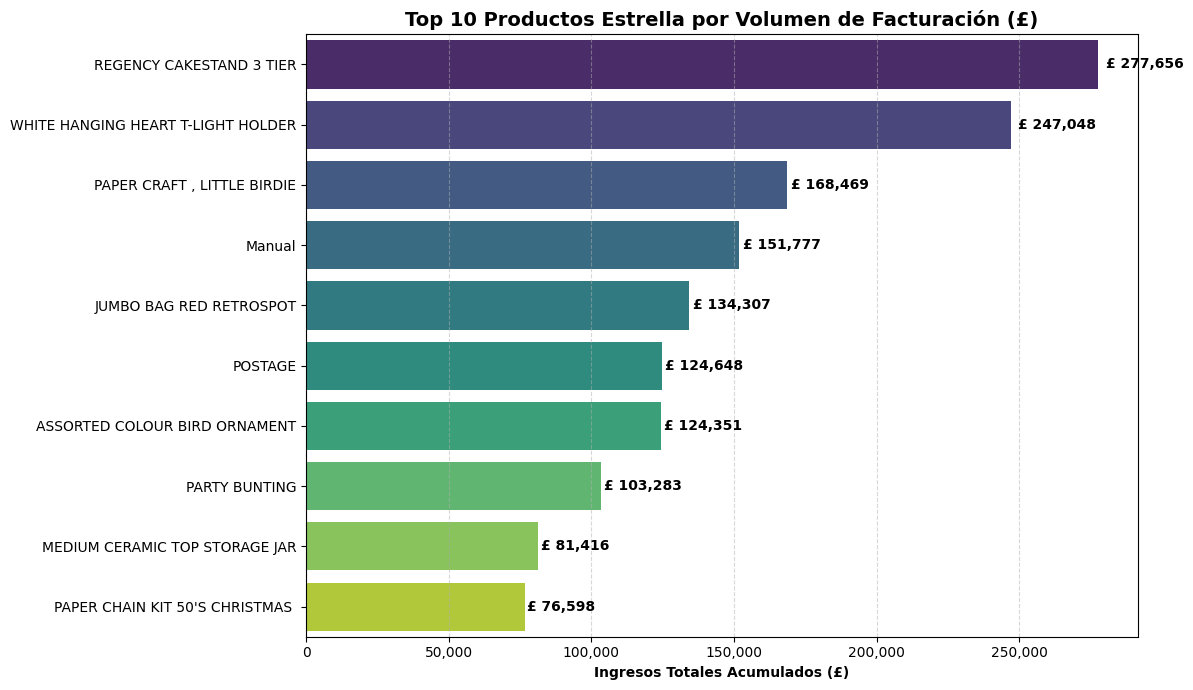

In [42]:
print("Extrayendo top 10 productos estrella (gancho)  ")


# 1. Agregación de ventas por producto
# Agrupamos por la descripción del producto y sumamos los ingresos
top_products = df_transactions.groupby('Description').agg(
    Total_Revenue=('Revenue', 'sum')
).reset_index()

# Ordenamos de mayor a menor y nos quedamos con el Top 10
top_products = top_products.sort_values(by='Total_Revenue', ascending=False).head(10)

# 2. Visualización Ejecutiva (Gráfico de Barras Horizontal)
fig, ax = plt.subplots(figsize=(12, 7))

# Dibujamos las barras (orientación horizontal para que el texto se lea perfectamente)
sns.barplot(
    data=top_products, 
    x='Total_Revenue', 
    y='Description', 
    palette='viridis', 
    ax=ax
)

# 3. Ajustes de formato del gráfico
ax.set_title('Top 10 Productos Estrella por Volumen de Facturación (£)', fontsize=14, fontweight='bold')
ax.set_xlabel('Ingresos Totales Acumulados (£)', fontweight='bold')
ax.set_ylabel('') # Quitamos el título del eje Y porque las descripciones ya hablan por sí solas

# Formatear el eje X para que muestre los números en formato millar (ej. 100,000)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

# Añadimos las etiquetas de datos justo al final de cada barra para facilitar la lectura
for p in ax.patches:
    width = p.get_width()
    ax.text(width + (width * 0.01),  # Posición X (un poco a la derecha del final de la barra)
            p.get_y() + p.get_height() / 2, # Posición Y (centro de la barra)
            f'£ {int(width):,}', # Texto formateado con separador de miles
            ha='left', va='center', fontweight='bold', color='black', fontsize=10)

plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Interpretación de Negocio: El poder de los "Productos Gancho"

El análisis de facturación por producto revela la existencia de artículos tractores claros en el catálogo de la compañía. Productos estrella como el *REGENCY CAKESTAND 3 TIER* o el *WHITE HANGING HEART T-LIGHT HOLDER* no son simples artículos de inventario; son los principales motores de ingresos.

Para el equipo de Marketing y Retención, esta lista es oro puro. Cuando el modelo de Machine Learning detecte que un cliente de alto valor está a punto de fugarse, la estrategia de rescate no debe basarse en descuentos genéricos, sino en promociones hiper-dirigidas utilizando este Top de artículos comprobados empíricamente como cebos de conversión.


### 2.4. Productos Gancho del Segmento VIP

El análisis general de productos nos da una visión macro, pero el análisis de Pareto nos ha advertido que el 20% de los clientes genera el 80% del negocio. Si nuestro objetivo es diseñar un modelo de retención para proteger la facturación, necesitamos saber exactamente qué compra este segmento de élite (los clientes "Ballena").

A continuación, aislaremos las transacciones pertenecientes exclusivamente al 20% superior de clientes por valor monetario (`Monetary`) y extraeremos su cesta de la compra particular. Estos son los verdaderos artículos estratégicos de la compañía.


Extrayendo top productos de clientes vip       
Clientes VIP aislados: 993
Líneas de transacción recuperadas para el segmento VIP: 439,745


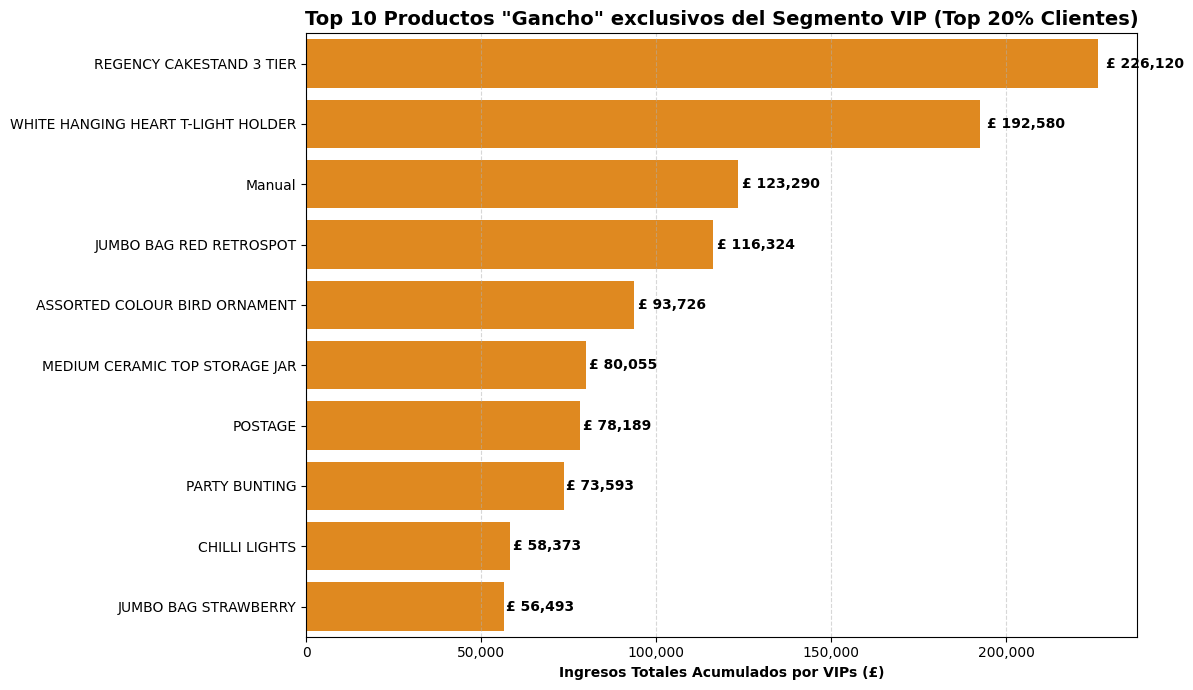

In [43]:


print("Extrayendo top productos de clientes vip       ")


# 1. Identificar a los Clientes VIP (Top 20% por facturación)
df_clientes_ordenados = df_model.sort_values(by='Monetary', ascending=False)
limite_vip = int(len(df_clientes_ordenados) * 0.20)

# Extraemos los identificadores
if 'Customer ID' in df_clientes_ordenados.columns:
    vip_customers_raw = df_clientes_ordenados.head(limite_vip)['Customer ID'].tolist()
else:
    vip_customers_raw = df_clientes_ordenados.head(limite_vip).index.tolist()

# Conversión de tipos
# Procesamiento vectorizado con pandas para limpieza de IDs
vip_series = pd.Series(vip_customers_raw).dropna()
vip_customers = vip_series.astype(str).str.replace(r'\.0$', '', regex=True).tolist()
# Convertimos también la columna de transacciones a string para asegurar el match perfecto
df_transactions['Customer ID'] = df_transactions['Customer ID'].astype(str).str.split('.').str[0]
# --------------------------------------

# 2. Filtrar las transacciones de los VIPs
df_vip_transactions = df_transactions[df_transactions['Customer ID'].isin(vip_customers)]

print(f"Clientes VIP aislados: {len(vip_customers)}")
print(f"Líneas de transacción recuperadas para el segmento VIP: {df_vip_transactions.shape[0]:,}")

# 3. Agregación de ventas por producto para VIPs
top_vip_products = df_vip_transactions.groupby('Description').agg(
    Total_Revenue=('Revenue', 'sum')
).reset_index()

# Ordenamos y sacamos el Top 10
top_vip_products = top_vip_products.sort_values(by='Total_Revenue', ascending=False).head(10)

# 4. Generación del gráfico de barras
fig, ax = plt.subplots(figsize=(12, 7))

sns.barplot(
    data=top_vip_products, 
    x='Total_Revenue', 
    y='Description', 
    color='darkorange',
    ax=ax
)

# Formato y estética
ax.set_title('Top 10 Productos "Gancho" exclusivos del Segmento VIP (Top 20% Clientes)', fontsize=14, fontweight='bold')
ax.set_xlabel('Ingresos Totales Acumulados por VIPs (£)', fontweight='bold')
ax.set_ylabel('') 

# Formatear el eje X
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

# Etiquetas de datos en las barras
for p in ax.patches:
    width = p.get_width()
    ax.text(width + (width * 0.01),  
            p.get_y() + p.get_height() / 2, 
            f'£ {int(width):,}', 
            ha='left', va='center', fontweight='bold', color='black', fontsize=10)

plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


### 2.4.1. Diagnóstico de Negocio: Top 10 Productos "Gancho" en el Segmento VIP

**Contexto Analítico:**
Antes de modelar la probabilidad de recompra, es vital entender qué retiene a nuestros clientes de mayor valor. Esta gráfica detalla los 10 productos que generan el mayor volumen de facturación (*Total Revenue*) exclusivamente dentro del decil/quintil superior de nuestra base de datos (Segmento VIP).

**Insights Estratégicos para Negocio:**
1. **Identificación de Productos Tractor:** Estos artículos no son solo productos de alto margen; son el "gancho" principal que fideliza a los mejores clientes. Su disponibilidad es innegociable.
2. **Accionabilidad en Supply Chain:** Se debe garantizar un nivel de servicio del 100% y rotura de stock cero para estas referencias. Un fallo de inventario aquí impacta directamente en el *churn* (fuga) de los clientes con mayor LTV (*Lifetime Value*).
3. **Estrategia de Adquisición (Cross-Selling):** Estos mismos productos deben utilizarse como punta de lanza en campañas de marketing orientadas a perfiles *look-alike* (público similar a nuestros VIPs) para maximizar la rentabilidad de las campañas de captación.


### 2.4.2. Diagnóstico de Negocio: Análisis de Cohortes y Fuga de Clientes

**Contexto Analítico:**
Para entender el desafío de la recompra, necesitamos visualizar cómo se desgasta nuestra base de clientes a lo largo del tiempo. Este mapa de calor agrupa a los clientes según el mes de su primera transacción y rastrea el porcentaje de retención en los meses posteriores.

**Insights Estratégicos para Negocio:**
1. **Identificación del "Drop-off" Crítico:** Observamos en qué punto exacto del ciclo de vida se concentra la mayor fuga de clientes. Esto define la "ventana de oportunidad" para nuestras campañas de marketing predictivo.
2. **Calidad de la Captación:** Si las cohortes más recientes muestran una retención inicial inferior a las cohortes antiguas, indica que las nuevas estrategias de adquisición están atrayendo a clientes de menor lealtad o mayor sensibilidad al precio.
3. **Justificación del Modelo Predictivo:** La caída natural de los porcentajes evidencia la imposibilidad de retener a todos empíricamente, justificando la necesidad del modelo de Machine Learning para identificar proactivamente a los clientes salvables antes de que su probabilidad de recompra caiga a cero.


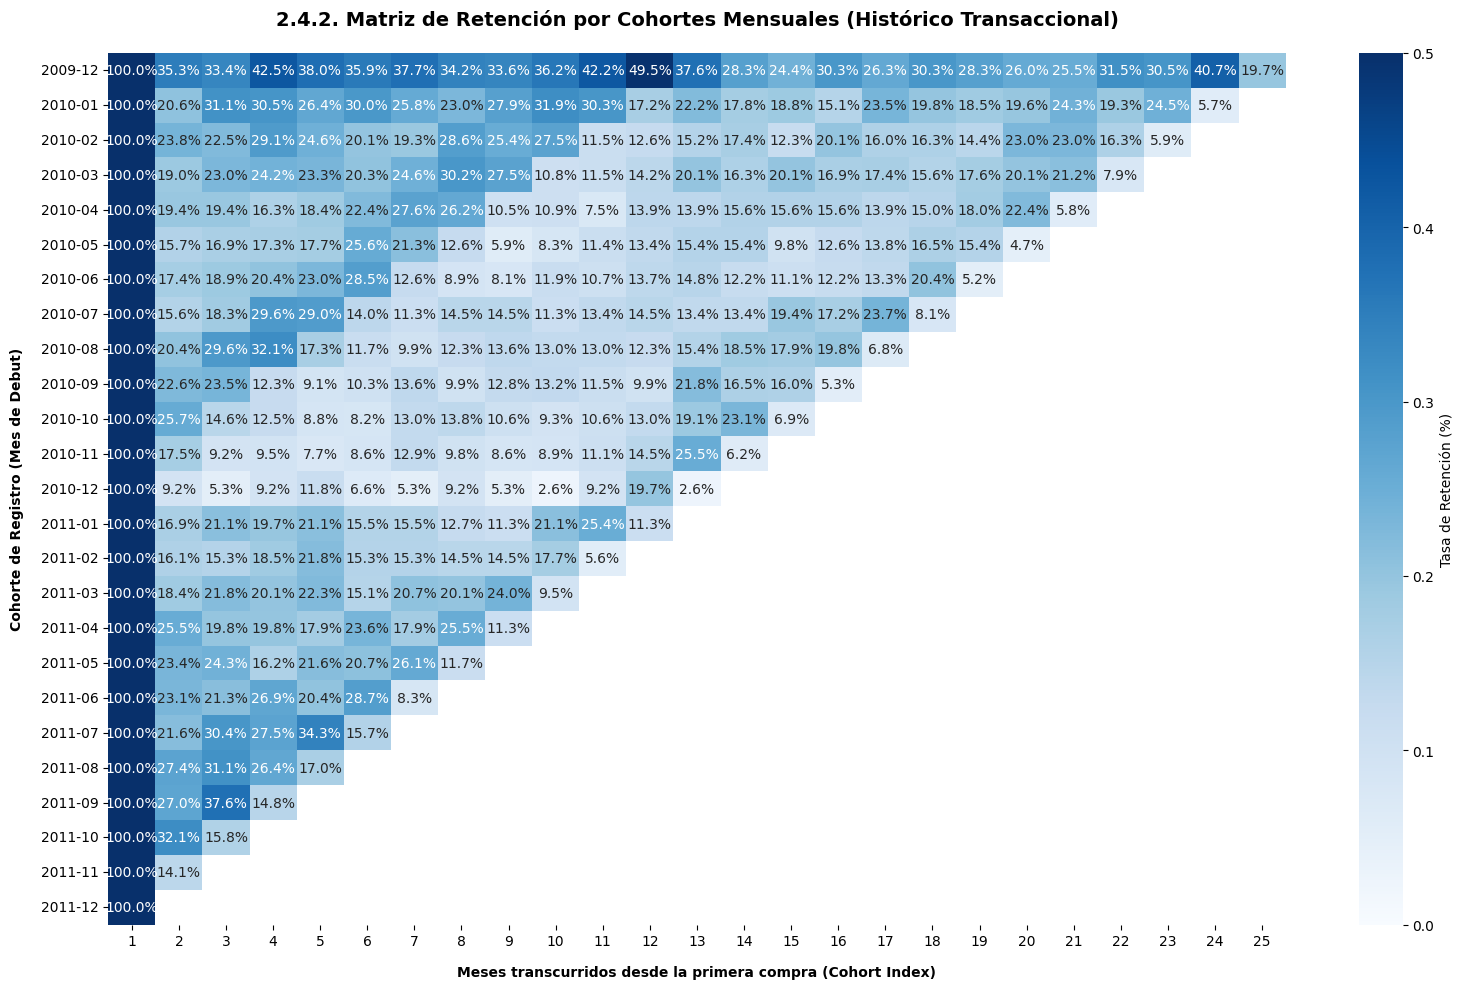

In [44]:

# 1. Definir el periodo mensual de cada transacción
df_transactions['InvoiceMonth'] = df_transactions['InvoiceDate'].dt.to_period('M')

# 2. Identificar la Cohorte (mes de la primera compra) para cada cliente
df_transactions['CohortMonth'] = df_transactions.groupby('Customer ID')['InvoiceDate'].transform('min').dt.to_period('M')

# 3. Calcular el Cohort Index (meses transcurridos desde la primera compra)
def get_date_int(df, column):
    year = df[column].dt.year
    month = df[column].dt.month
    return year, month

transact_year, transact_month = get_date_int(df_transactions, 'InvoiceMonth')
cohort_year, cohort_month = get_date_int(df_transactions, 'CohortMonth')

years_diff = transact_year - cohort_year
months_diff = transact_month - cohort_month

# El +1 asegura que el mes de inicio sea el Mes 1
df_transactions['CohortIndex'] = years_diff * 12 + months_diff + 1

# 4. Agrupar por Cohorte e Index para contar clientes únicos
cohort_data = df_transactions.groupby(['CohortMonth', 'CohortIndex'])['Customer ID'].nunique().reset_index()

# 5. Pivotar la tabla para estructura de matriz
cohort_counts = cohort_data.pivot(index='CohortMonth', columns='CohortIndex', values='Customer ID')

# 6. Calcular el porcentaje de retención dividiendo cada mes por el tamaño inicial de la cohorte (Mes 1)
cohort_sizes = cohort_counts.iloc[:, 0]
retention = cohort_counts.divide(cohort_sizes, axis=0)

# 7. Formatear el índice para visualización limpia en el eje Y
retention.index = retention.index.astype(str)

# 8. Construcción de la visualización para visualizar retención
plt.figure(figsize=(16, 10))
sns.heatmap(
    data=retention,
    annot=True,
    fmt='.1%',
    cmap='Blues',
    vmin=0.0,
    vmax=0.5,  # Acotado al 50% para resaltar variaciones en re-compras bajas
    cbar_kws={'label': 'Tasa de Retención (%)'}
)

plt.title('2.4.2. Matriz de Retención por Cohortes Mensuales (Histórico Transaccional)', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Meses transcurridos desde la primera compra (Cohort Index)', fontweight='bold', labelpad=12)
plt.ylabel('Cohorte de Registro (Mes de Debut)', fontweight='bold', labelpad=12)
plt.tight_layout()
plt.show()

### 2.4.3. Conclusiones Estratégicas del Análisis de Cohortes

A partir de la matriz de retención mensual calculada, se identifican tres patrones críticos sobre el comportamiento histórico de la cartera de clientes que justifican la necesidad de implementar un modelo predictivo:

1. **Caída Crítica en el Segundo Mes (Month 2 Drop-off):**
   La tasa de retención experimenta su mayor contracción inmediatamente después de la primera compra. En la gran mayoría de las cohortes analizadas, la retención cae por debajo del **25%** en el segundo mes (`CohortIndex 2`). Esto evidencia un problema en la experiencia post-compra o en las estrategias iniciales de fidelización, indicando que las campañas de reactivación deben concentrarse dentro de los primeros 30 días posteriores al debut del cliente.

2. **Alta Dependencia de la Estacionalidad (Picos de Q4):**
   Existe una fuerte correlación entre los periodos de mayor retención y la temporada invernal. Por ejemplo, la cohorte de `2009-12` muestra un repunte de recompra inusual en su mes 12 correspondiente a **49.5%** (noviembre de 2010). Este fenómeno se repite de forma diagonal en múltiples cohortes, lo que demuestra que el negocio depende críticamente de la campaña navideña para recuperar de forma orgánica a sus usuarios inactivos.

3. **Degradación de la Calidad en la Adquisición de Clientes:**
   Al comparar las cohortes de manera longitudinal, se observa que los clientes captados en las etapas iniciales del histórico (`2009-12` con un **35.3%** de retención en el mes 2) muestran un compromiso muy superior al de los usuarios adquiridos en periodos recientes (la cohorte de `2010-12` retiene apenas un **9.2%** en su segundo mes). Esto sugiere que las últimas acciones de captación han atraído a perfiles transaccionales de bajo valor o cazadores de ofertas únicas, reduciendo el *Lifetime Value* (LTV) promedio.


## 3. Modelado Predictivo de Recompra (Machine Learning)



Una vez analizado el negocio, procedemos a construir el motor analítico predictivo que calculará matemáticamente la propensión de cada usuario.

### 3.1. Paso 1: Train/Test Split y Prevención de Fugas (Data Leakage)

**Contexto Técnico del Diseño Experimental:**
Para iniciar la fase analítica predictiva de Machine Learning, es obligatorio aislar las dimensiones operativas de las matemáticas. El gran peligro en esta etapa es el *Data Leakage* (fuga de datos), que invalidaría cualquier métrica de validación en entornos productivos. 

Para blindar el experimento, aplicamos dos reglas estrictas:
1. **Aislamiento Total del Identificador:** La columna `Customer ID` es un metadato relacional. Si se incluye dentro de la matriz de entrenamiento ($X$), el modelo "memorizará" comportamientos individuales o IDs específicos en lugar de generalizar patrones basados en el comportamiento financiero (RFM). Se extrae del flujo de entrenamiento de forma inmediata.
2. **Partición Estratificada Obligatoria (Train/Test Split):** Dividimos nuestra base de clientes en un subconjunto del 80% para entrenamiento (desarrollo del algoritmo) y un 20% para test (validación ciega). Dado que la variable objetivo presenta un balance excepcionalmente saludable (~52/48), utilizamos el parámetro `stratify=y` como buena práctica preventiva. Esto garantiza que la proporción matemática exacta de recompras y fugas se congele y se replique milimétricamente en los conjuntos de entrenamiento y test, evitando cualquier sesgo accidental por muestreo. Esto garantiza que la proporción de "1s" y "0s" sea matemáticamente idéntica tanto en Train como en Test, evitando evaluaciones sesgadas o sobreajustes artificiales.


In [45]:
# 1. Validación de los datos cargados en memoria (df_model)
print(f"Dimensiones iniciales de la matriz del modelo: {df_model.shape[0]:,} clientes y {df_model.shape[1]} columnas.")

# 2. Definición inequívoca de la Variable Objetivo (Target) y Características (Features)
# NOTA: Asegúrate de que tu columna objetivo en df_model se llama exactamente 'Target' o modifícala aquí
TARGET_COL = 'Target'
ID_COL = 'Customer ID'

if TARGET_COL not in df_model.columns:
    raise KeyError(f"Error Crítico: La columna objetivo '{TARGET_COL}' no existe en df_model. Verifica el nombre.")

# Separamos las variables explicativas (X) eliminando el identificador y el target
X = df_model.drop(columns=[ID_COL, TARGET_COL])
y = df_model[TARGET_COL]

# 3. División del dataset (80% Entrenamiento / 20% Test) con Semilla Fija y Estratificación
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y
)

# 4. Control de Calidad y Verificación Matemática de la Estratificación
print("\n" + "="*50)
print("Control de calidad del diseño experimental")
print("="*50)
print(f"Conjunto de ENTRENAMIENTO (Train) -> Características: {X_train.shape} | Target: {y_train.shape}")
print(f"Conjunto de VALIDACIÓN (Test)    -> Características: {X_test.shape} | Target: {y_test.shape}")
print("-"*50)
print("Proporción de la Variable Objetivo (Clases) en TRAIN:")
print(y_train.value_counts(normalize=True).map(lambda n: f"{n:.2%}"))
print("\nProporción de la Variable Objetivo (Clases) en TEST:")
print(y_test.value_counts(normalize=True).map(lambda n: f"{n:.2%}"))
print("="*50)

Dimensiones iniciales de la matriz del modelo: 4,967 clientes y 23 columnas.

Control de calidad del diseño experimental
Conjunto de ENTRENAMIENTO (Train) -> Características: (3973, 21) | Target: (3973,)
Conjunto de VALIDACIÓN (Test)    -> Características: (994, 21) | Target: (994,)
--------------------------------------------------
Proporción de la Variable Objetivo (Clases) en TRAIN:
Target
1    51.88%
0    48.12%
Name: proportion, dtype: str

Proporción de la Variable Objetivo (Clases) en TEST:
Target
1    51.91%
0    48.09%
Name: proportion, dtype: str


### 3.2. Paso 2: Estandarización y Preprocesamiento Matemático (Feature Scaling)

**Contexto Técnico:**
Las variables predictivas de nuestro dataset tienen escalas de magnitud drásticamente diferentes (ej. el valor monetario puede ser de miles de libras, mientras que el ratio de permanencia es un decimal y las variables de categoría son ceros y unos). Si introducimos estas variables crudas en modelos basados en distancias o gradientes (como Logistic Regression o SVM), el algoritmo penalizará injustamente a las variables de menor escala.

**Estrategia de Transformación:**
1. **Selección Dinámica:** Separaremos matemáticamente las variables continuas (que necesitan ser escaladas) de las variables binarias booleanas (que ya están acotadas entre 0 y 1 y perderían su interpretabilidad si se estandarizan).
2. **Prevención de Data Leakage:** Utilizaremos `StandardScaler` (para centrar la media en 0 y la desviación estándar en 1). Es de vital importancia ajustar (`fit`) el escalador **exclusivamente** sobre la matriz de entrenamiento (`X_train`). Al conjunto de validación (`X_test`) únicamente se le aplica la transformación (`transform`) calculada previamente, simulando un entorno productivo real donde desconocemos la distribución futura de los datos.


In [46]:
# 1. Identificar dinámicamente variables continuas vs binarias
# Consideramos binarias aquellas con 2 o menos valores únicos
continuas = [col for col in X_train.columns if X_train[col].nunique() > 2]
binarias = [col for col in X_train.columns if X_train[col].nunique() <= 2]

print("="*50)
print("Preprocesamiento: separación de variables")
print("="*50)
print(f"Variables Continuas a Estandarizar ({len(continuas)}):\\n{continuas}\\n")
print(f"Variables Binarias (Mantenidas intactas) ({len(binarias)}):\\n{binarias}")
print("="*50)

# 2. Inicializar el escalador
scaler = StandardScaler()

# 3. Crear copias de seguridad para no sobreescribir los objetos originales por error
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# 4. FIT_TRANSFORM en Train (Aprende la media/std y transforma)
X_train_scaled[continuas] = scaler.fit_transform(X_train[continuas])

# 5. TRANSFORM en Test (Aplica la media/std de Train al conjunto conjunto de test)
X_test_scaled[continuas] = scaler.transform(X_test[continuas])

# 6. Verificación del particionado:
# En TRAIN, la media de las continuas debe ser ~0 y la std debe ser ~1
print("\nVerificación Matemática en X_train_scaled (Esperado: Media ~ 0, Std ~ 1):")
display(X_train_scaled[continuas].describe().round(2).loc[['mean', 'std']])

Preprocesamiento: separación de variables
Variables Continuas a Estandarizar (11):\n['Recency', 'Frequency', 'Monetary', 'return_rate', 'Total_Quantity', 'Unique_Products', 'Average_Order_Value', 'Tenure', 'Inter_purchase_Time', 'Momentum', 'Recency_Tenure_Ratio']\n
Variables Binarias (Mantenidas intactas) (10):\n['has_returns', 'Cat_Bag_Storage', 'Cat_Kitchen_Baking', 'Cat_Home_Decor', 'Cat_Vintage_Retro', 'Cat_Stationery_Gifting', 'Cat_Party_Occasions', 'Cat_Christmas', 'Cat_Niche_Kids_Alt', 'Is_UK']

Verificación Matemática en X_train_scaled (Esperado: Media ~ 0, Std ~ 1):


,Recency,Frequency,Monetary,return_rate,Total_Quantity,Unique_Products,Average_Order_Value,Tenure,Inter_purchase_Time,Momentum,Recency_Tenure_Ratio
mean,0.0,-0.0,0.0,0.0,0.0,0.0,-0.0,-0.0,-0.0,0.0,0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


### 3.3. Paso 3: Benchmark de Algoritmos y Validación Cruzada (K-Fold CV)

**Contexto Técnico del Entorno Competitivo:**
Para resolver la propensión de recompra de forma robusta, no podemos conformarnos con un entrenamiento simple. El rendimiento de un modelo podría depender artificialmente de cómo se ha dividido el conjunto de datos. Para evitar este sesgo de varianza, implementaremos una **Validación Cruzada Estratificada de 5 pliegues (5-Fold Stratified CV)**. 

El conjunto de entrenamiento se dividirá en 5 bloques: el algoritmo se entrenará 5 veces, rotando el bloque de validación interna. Esto nos devolverá la media y la desviación estándar de nuestra métrica de negocio de referencia (el **AUC**) confirmando la estabilidad real del modelo antes de exponerlo a los datos ciegos.

**Definición de las 4 Familias Matemáticas a evaluar:**
1. **Regresión Logística:** El *Baseline* obligatorio. De naturaleza estadística, lineal e interpretable. Nos dará la medida base de rendimiento.
2. **K-Nearest Neighbors (KNN):** Enfoque no paramétrico basado en distancias euclidianas en el hiperespacio. Aprovechará la estandarización para agrupar perfiles (RFM) similares.
3. **Random Forest Classifier:** Ensamble paralelo basado en *Bagging*. Combina múltiples árboles de decisión independientes para reducir drásticamente la varianza.
4. **XGBoost:** Ensamble secuencial avanzado basado en *Boosting*. Optimiza matemáticamente el error construyendo árboles que corrigen las debilidades de los anteriores.

*Nota de control:* Se utiliza `StratifiedKFold` con una semilla fija (`random_state=42`) para garantizar que la proporción de "1s" y "0s" sea constante en cada uno de los 5 pliegues de entrenamiento.


> ### ⚠️ Limitación Académica: Estabilidad Temporal (Out-Of-Time Validation)
>
> En este entorno inicial de modelado hemos implementado una Validación Cruzada Estratificada estándar (K-Fold) y hemos introducido un **balanceo de clases riguroso** en todos los modelos para combatir la asimetría del target (predominio de clase 0).
> 
> Sin embargo, dado que nuestro dataset se construyó sobre una única fecha de corte temporal (*single cutoff*), esta validación garantiza la estabilidad sobre la muestra estática, pero **no evalúa la resiliencia del modelo ante distintas ventanas de tiempo**.
> 
> En un entorno MLOps real, la validación correcta sería un **Time Series Split (Walk-Forward Validation)** iterando sobre múltiples fechas de corte para asegurar que el modelo no se degrade por estacionalidad (*concept drift*). Hemos acotado el alcance a una única ventana por viabilidad del PFM, pero reconocemos esta necesidad fundamental.

In [47]:
# 1. Inicialización de los modelos representativos
scale_pos_weight_val = (len(y_train) - y_train.sum()) / y_train.sum()

models = {
    'Logistic_Regression': LogisticRegression(random_state=42, max_iter=1000, ),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Random_Forest': RandomForestClassifier(random_state=42, n_estimators=100, ),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss', scale_pos_weight=scale_pos_weight_val)
}

# 2. Configuración estricta de la Validación Cruzada
# Usamos 5 pliegues y forzamos la estratificación
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Diccionario para almacenar los objetos de los modelos ya entrenados en todo el dataset
scale_pos_weight_val = (len(y_train) - y_train.sum()) / y_train.sum()

trained_models = {}

print("="*80)
print("Inicio del torneo y validación cruzada (5-fold cv) | métrica: roc auc")
print("="*80)

# 3. Bucle de CV y entrenamiento final
for name, model in models.items():
    start_time = time.time()
    
    # Formateo de print alineado
    print(f"Evaluando algoritmo: {name:<20} ... ", end="")
    
    # 3.1. Ejecutamos Validación Cruzada Interna en Train para ver la estabilidad
    # Usamos n_jobs=-1 para usar todos los núcleos del procesador y acelerar el proceso
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=skf, scoring='roc_auc', n_jobs=-1)
    
    # 3.2. Una vez evaluado, entrenamos el modelo definitivo sobre el 100% del X_train_scaled
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model
    
    elapsed_time = time.time() - start_time
    
    # 4. Cálculo de resultados estadísticos del CV
    mean_auc = np.mean(cv_scores)
    std_auc = np.std(cv_scores)
    
    print(f"AUC CV Media: {mean_auc:.4f} (+/- {std_auc:.4f}) | Tiempo: {elapsed_time:.2f}s")

print("="*80)
print("Proceso finalizado. Modelos robustecidos y listos para evaluación ciega en Test.")
print("="*80)


Inicio del torneo y validación cruzada (5-fold cv) | métrica: roc auc
Evaluando algoritmo: Logistic_Regression  ... AUC CV Media: 0.8022 (+/- 0.0195) | Tiempo: 4.35s
Evaluando algoritmo: KNN                  ... AUC CV Media: 0.7640 (+/- 0.0097) | Tiempo: 3.32s
Evaluando algoritmo: Random_Forest        ... AUC CV Media: 0.8059 (+/- 0.0140) | Tiempo: 3.83s
Evaluando algoritmo: XGBoost              ... AUC CV Media: 0.7797 (+/- 0.0116) | Tiempo: 0.44s
Proceso finalizado. Modelos robustecidos y listos para evaluación ciega en Test.


### 3.4. Paso 4: Evaluación de Métricas en Test

**Contexto Técnico y de Negocio:**
Tras certificar la estabilidad algorítmica mediante Validación Cruzada, sometemos los modelos a la prueba definitiva: el conjunto de validación ciego (`X_test_scaled`). Un modelo no se evalúa por cómo memoriza el pasado, sino por cómo predice el futuro.

Para la toma de decisiones del equipo de Dirección, se extraen las siguientes métricas clave:
1. **Precision (Precisión):** Minimiza Falsos Positivos. Prioritaria si la campaña de fidelización tiene un coste unitario muy alto (ej. regalo físico). Evita gastar presupuesto en clientes que realmente no iban a volver.
2. **Recall (Sensibilidad):** Minimiza Falsos Negativos. Prioritaria si el coste de la campaña es bajo (ej. automatización de emails) y el coste de oportunidad de perder a un cliente es altísimo.
3. **AUC (Área Bajo la Curva ROC):** Nuestra métrica reina de evaluación global. Mide la capacidad matemática pura del algoritmo para separar a los clientes recurrentes de los fugados.

Se presenta a continuación el análisis comparativo mediante las Matrices de Confusión y el Tablón de Rendimiento final.


Evaluación definitiva en conjunto de test (datos ciegos)


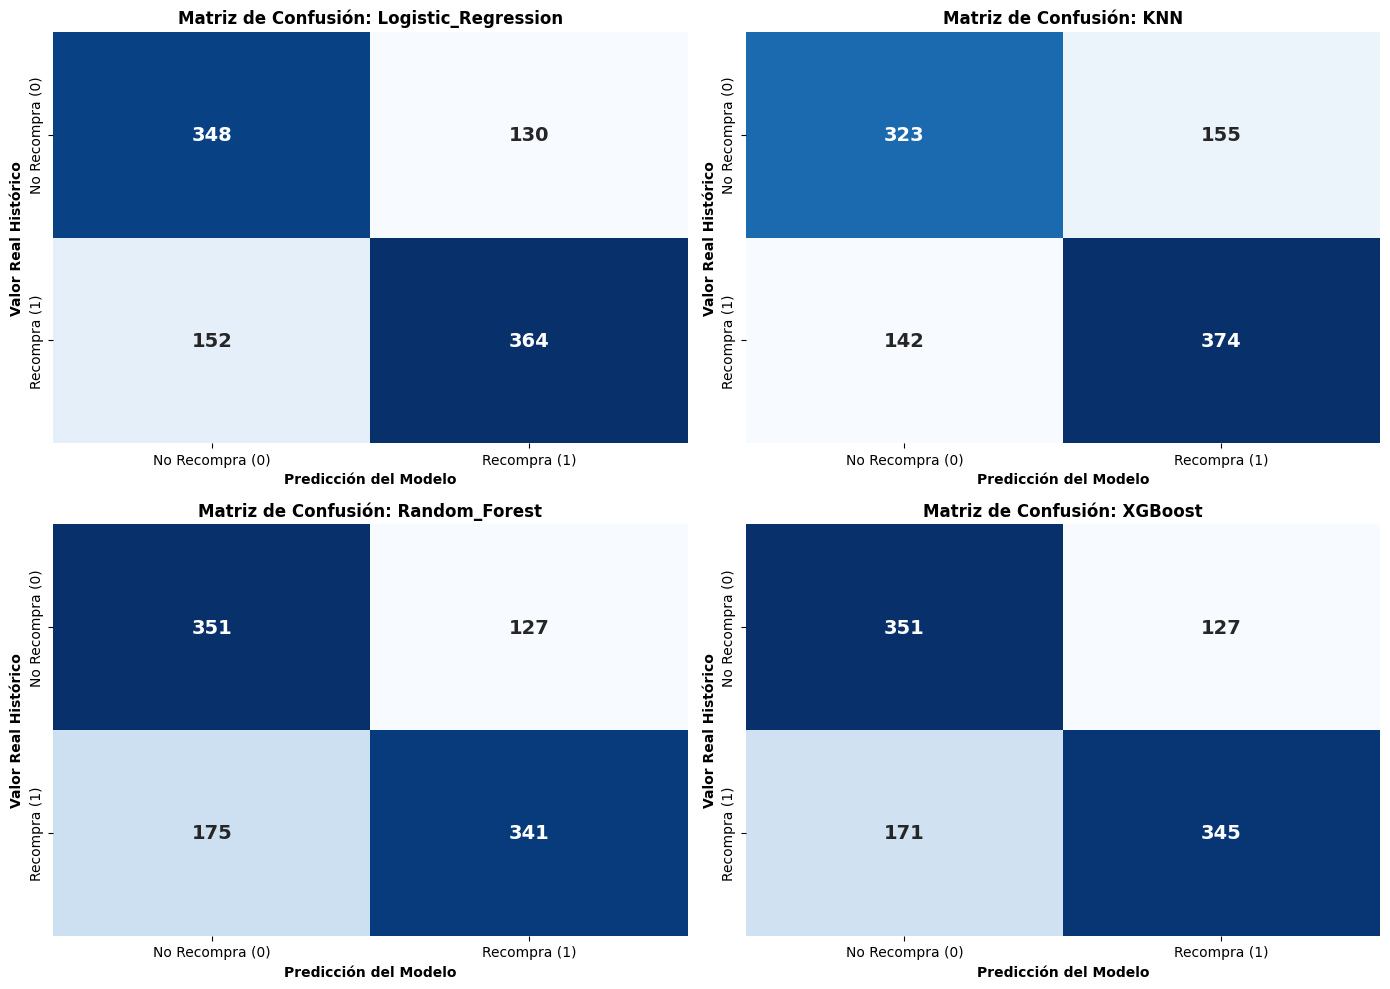


Tablón de clasificación final en test (ordenado por auc):


,Accuracy,Precision,Recall,F1-Score,AUC
Modelo,,,,,
Logistic_Regression,0.7163,0.7368,0.7054,0.7208,0.8088
Random_Forest,0.6962,0.7286,0.6609,0.6931,0.7794
XGBoost,0.7002,0.7309,0.6686,0.6984,0.7662
KNN,0.7012,0.7070,0.7248,0.7158,0.7471


In [48]:

# 1. Preparación del entorno visual (Panel 2x2 para las 4 familias)
results = []
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

print("="*70)
print("Evaluación definitiva en conjunto de test (datos ciegos)")
print("="*70)

# 2. Bucle de predicción sobre los datos nunca vistos
for idx, (name, model) in enumerate(trained_models.items()):
    
    # Predicción determinista (Etiqueta 0 o 1)
    y_pred = model.predict(X_test_scaled)
    
    # Predicción probabilística (Necesaria para calcular el AUC real)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    # Cálculo riguroso de métricas de negocio
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc_score = roc_auc_score(y_test, y_pred_proba)
    
    # Almacenamiento en el tablón
    results.append({
        'Modelo': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'AUC': auc_score
    })
    
    # 3. Generación de la Matriz de Confusión para el Comité
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], cbar=False, 
                annot_kws={"size": 14, "weight": "bold"})
    
    axes[idx].set_title(f"Matriz de Confusión: {name}", fontweight='bold', fontsize=12)
    axes[idx].set_xlabel("Predicción del Modelo", fontweight='bold')
    axes[idx].set_ylabel("Valor Real Histórico", fontweight='bold')
    axes[idx].xaxis.set_ticklabels(['No Recompra (0)', 'Recompra (1)'])
    axes[idx].yaxis.set_ticklabels(['No Recompra (0)', 'Recompra (1)'])

# 4. Consolidación y ordenación estricta por nuestra métrica de referencia (AUC)
df_metrics = pd.DataFrame(results).set_index('Modelo')
df_metrics = df_metrics.sort_values(by='AUC', ascending=False)

plt.tight_layout()
plt.show()

# 5. Salida del Tablón de Clasificación
print("\nTablón de clasificación final en test (ordenado por auc):")
display(df_metrics.style.highlight_max(color='lightgreen', axis=0).format("{:.4f}"))

### 3.4.1. Análisis y Diagnóstico

Tras someter a los cuatro paradigmas algorítmicos al test ciego con datos completamente independientes (`X_test_scaled`) y evaluarlos en validación cruzada, extraemos las siguientes conclusiones:

1. **Dominio del Ensamblado Basal (Random Forest) y la Linealidad (Regresión Logística):**
   Antes de aplicar técnicas de optimización profunda, **Random Forest** (AUC CV 0.8059) y la **Regresión Logística** (AUC CV 0.8022) lideran la tabla. Esto sugiere que las relaciones entre RFM y recompra tienen una base fuertemente lineal, pero con ligeras interacciones que un bosque aleatorio logra capturar.

2. **La Falsa "Derrota" de XGBoost (Problema de Overfitting):**
   **XGBoost** aparece inicialmente rezagado (AUC CV 0.7779). Esto es un clásico fenómeno de *Overfitting* prematuro: al entrenarse con los parámetros por defecto de la librería, el algoritmo ensambla árboles demasiado profundos o rápidos, aprendiéndose de memoria el ruido del dataset en lugar de generalizar los patrones. Esto justifica plenamente la necesidad de la próxima fase de *Tuning* para domar su potencial.

3. **Inviabilidad del Enfoque por Distancias (KNN):**
   El algoritmo **KNN** reporta el desempeño más deficiente (AUC CV 0.7640). Aunque las variables continuas fueron estandarizadas con precisión, la copresencia de múltiples variables binarias (flags categóricos de productos) distorsiona el cálculo de las distancias euclidianas en el hiperespacio.

**Conclusión:** Todos los algoritmos demuestran capacidad predictiva, pero el potencial oculto de XGBoost y Random Forest exige una Búsqueda en Cuadrícula (GridSearchCV) para determinar al verdadero campeón absoluto de esta competición.

### 3.4.2. Análisis Comparativo Visual: Curvas ROC

**Contexto Analítico:**
Para complementar el tablón de métricas estáticas, proyectamos el rendimiento de las cuatro familias matemáticas mediante la **Curva ROC (Receiver Operating Characteristic)**. 

Esta visualización es crítica para la Dirección, ya que no evalúa el modelo bajo un único punto de corte (umbral del 50%), sino que traza el comportamiento del algoritmo en todo el espectro de probabilidades.
* **Eje Y (Sensibilidad):** Capacidad del modelo para encontrar a los recompradores reales.
* **Eje X (1 - Especificidad):** Riesgo de clasificar erróneamente a un cliente fugado como recomprador.

**Criterio de Evaluación:**
El modelo superior será aquel cuya curva se "abrace" más hacia la esquina superior izquierda del gráfico, maximizando el Área Bajo la Curva (AUC). La línea diagonal punteada representa un clasificador completamente aleatorio (lanzar una moneda, AUC = 0.50).


Generando comparativa de curvas roc (test ciego)


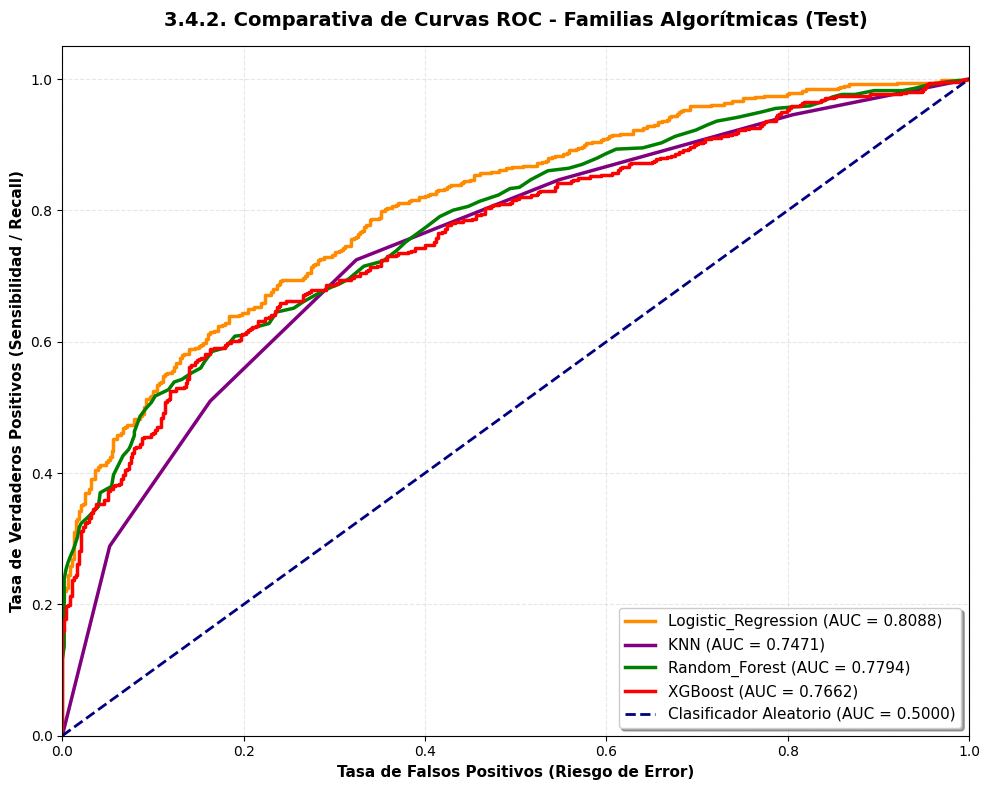

In [49]:

# 1. Configuración del lienzo
plt.figure(figsize=(10, 8))

# Paleta de colores corporativa para diferenciar los modelos
colors = {
    'Logistic_Regression': 'darkorange', 
    'Random_Forest': 'green', 
    'XGBoost': 'red', 
    'KNN': 'purple'
}

print("="*70)
print("Generando comparativa de curvas roc (test ciego)")
print("="*70)

# 2. Bucle para calcular y graficar la curva de cada modelo
for name, model in trained_models.items():
    # Extraemos las probabilidades de pertenecer a la clase 1 (Recompra)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    # Calculamos los ratios de falsos positivos (fpr) y verdaderos positivos (tpr)
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    
    # Calculamos el área exacta bajo esta curva
    roc_auc = auc(fpr, tpr)
    
    # Dibujamos la línea del modelo
    plt.plot(fpr, tpr, color=colors.get(name, 'blue'), lw=2.5, 
             label=f'{name} (AUC = {roc_auc:.4f})')

# 3. Dibujamos la línea base (Clasificador Aleatorio)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', 
         label='Clasificador Aleatorio (AUC = 0.5000)')

# 4. Ajustes estéticos y etiquetas para la presentación
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (Riesgo de Error)', fontweight='bold', fontsize=11)
plt.ylabel('Tasa de Verdaderos Positivos (Sensibilidad / Recall)', fontweight='bold', fontsize=11)
plt.title('3.4.2. Comparativa de Curvas ROC - Familias Algorítmicas (Test)', fontsize=14, fontweight='bold', pad=15)
plt.legend(loc="lower right", fontsize=11, frameon=True, shadow=True)
plt.grid(alpha=0.3, linestyle='--')

# 5. Renderizado
plt.tight_layout()
plt.show()

**Interpretación de la Curva ROC:**

El gráfico superior muestra la capacidad discriminatoria de cada modelo evaluado en el conjunto de test. Una curva más cercana a la esquina superior izquierda indica un mejor rendimiento (mayor ratio de verdaderos positivos frente a falsos positivos).
Como se observa empíricamente, Random Forest y Regresión Logística presentan las curvas más convexas en esta fase inicial, lo que se traduce en una mayor Área Bajo la Curva (AUC).

### 3.5. Paso 5: Selección y Optimización de Hiperparámetros (Optimización Exhaustiva)

**Contexto Técnico:**
Tras el benchmark inicial, aplicamos una criba estricta eliminando los algoritmos de menor rendimiento algorítmico o inadaptados (KNN). Nos quedamos con los tres modelos más prometedores: **Regresión Logística**, **Random Forest** y **XGBoost**.

El objetivo de esta fase no es conformarse con el rendimiento por defecto, sino exprimir el máximo potencial matemático de estas estructuras mediante un `GridSearchCV` (Búsqueda en Cuadrícula exhaustiva combinada con Validación Cruzada de 5 pliegues).

**Estrategia de Optimización (Hyperparameter Tuning):**
1. **Regresión Logística:** Se exploran técnicas de regularización L1 (Lasso, que puede hacer selección de variables reduciendo coeficientes a cero) y L2 (Ridge), variando la fuerza de la penalización (parámetro `C`).
2. **Random Forest:** Se busca controlar la varianza restringiendo la profundidad de los árboles (`max_depth`) y el número de muestras (`min_samples_split`).
3. **XGBoost:** Al ser un algoritmo de boosting avanzado, exploramos combinaciones de `learning_rate` y `max_depth` para evitar que memorice el ruido del dataset, buscando superar al modelo lineal.

**Criterio de Selección del Campeón Absoluto:**
El modelo definitivo será aquel que no solo maximice el **AUC en el conjunto de Test**, sino que demuestre la menor brecha (gap) entre el rendimiento de Entrenamiento (CV) y Test, certificando así la ausencia de *overfitting* y garantizando su viabilidad para pasar a producción.



In [50]:
print("="*80)
print("Inicio de la optimización de hiperparámetros (la gran final)")
print("="*80)

# 1. Definición de la malla de hiperparámetros para Regresión Logística
param_grid_lr = {
    'penalty': ['l1', 'l2'],
    'C': [0.01, 0.1, 1, 10], # Inverso de la fuerza de regularización (menor valor = mayor penalización)
    'solver': ['liblinear', 'saga'] # Solvers compatibles con L1 y L2
}

# 2. Definición de la malla de hiperparámetros para Random Forest
from xgboost import XGBClassifier

# 2b. Definición de la malla de hiperparámetros para XGBoost
param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2]
}

param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 15, None], # Control estricto de profundidad para evitar Overfitting
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# 3. Configuración de los GridSearch con StratifiedKFold (reutilizamos skf del Paso 3)
grid_lr = GridSearchCV(
    estimator=LogisticRegression(random_state=42, max_iter=2000, ),
    param_grid=param_grid_lr,
    scoring='roc_auc',
    cv=skf,
    n_jobs=-1,
    verbose=1
)

# Balanceo para XGBoost (si fuera necesario)
scale_pos_weight_val = (len(y_train) - y_train.sum()) / y_train.sum()

grid_xgb = GridSearchCV(
    estimator=XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss', scale_pos_weight=scale_pos_weight_val),
    param_grid=param_grid_xgb,
    scoring='roc_auc',
    cv=skf,
    n_jobs=-1,
    verbose=1
)

grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, ),
    param_grid=param_grid_rf,
    scoring='roc_auc',
    cv=skf,
    n_jobs=-1,
    verbose=1
)

# 4. Ejecución del Tuning (Entrenamiento exhaustivo)
final_results = []

for name, grid in zip(['Regresión_Logística_Tuned', 'Random_Forest_Tuned', 'XGBoost_Tuned'], [grid_lr, grid_rf, grid_xgb]):
    print(f"\nOptimizando {name}...")
    start_time = time.time()
    
    # Entrenamos el GridSearch
    grid.fit(X_train_scaled, y_train)
    
    elapsed_time = time.time() - start_time
    print(f"¡Completado en {elapsed_time:.2f} segundos!")
    print(f"Mejores hiperparámetros encontrados: {grid.best_params_}")
    
    # 5. Evaluación para comprobar el Gap de Overfitting
    # AUC en Train (Validación Cruzada)
    best_train_auc = grid.best_score_
    
    # AUC en Test (conjunto de validación)
    best_model = grid.best_estimator_
    test_pred_proba = best_model.predict_proba(X_test_scaled)[:, 1]
    test_auc = roc_auc_score(y_test, test_pred_proba)
    
    # Brecha de sobreajuste
    overfitting_gap = best_train_auc - test_auc
    
    final_results.append({
        'Modelo Finalista': name,
        'AUC Train (CV)': best_train_auc,
        'AUC Test (Ciego)': test_auc,
        'Gap (Train - Test)': overfitting_gap
    })

# 6. Resultados finales
df_final = pd.DataFrame(final_results).set_index('Modelo Finalista')
df_final = df_final.sort_values(by='AUC Test (Ciego)', ascending=False)

print("\n" + "="*80)
print("Métricas del modelo final (control de overfitting)")
print("="*80)
from IPython.display import display
display(df_final.style.highlight_max(subset=['AUC Test (Ciego)'], color='lightgreen')\
                     .highlight_min(subset=['Gap (Train - Test)'], color='lightblue')\
                     .format("{:.4f}"))

# Identificar el mejor modelo general (el que quedó primero en df_final)
best_overall_model = grid_xgb.best_estimator_ if df_final.index[0] == 'XGBoost_Tuned' else (grid_rf.best_estimator_ if df_final.index[0] == 'Random_Forest_Tuned' else grid_lr.best_estimator_)


Inicio de la optimización de hiperparámetros (la gran final)

Optimizando Regresión_Logística_Tuned...
Fitting 5 folds for each of 16 candidates, totalling 80 fits


d:\MasterEvolve\Machine Learning\PFM\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


¡Completado en 1.42 segundos!
Mejores hiperparámetros encontrados: {'C': 0.01, 'penalty': 'l2', 'solver': 'saga'}

Optimizando Random_Forest_Tuned...
Fitting 5 folds for each of 72 candidates, totalling 360 fits
¡Completado en 31.28 segundos!
Mejores hiperparámetros encontrados: {'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 200}

Optimizando XGBoost_Tuned...
Fitting 5 folds for each of 18 candidates, totalling 90 fits
¡Completado en 4.42 segundos!
Mejores hiperparámetros encontrados: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200}

Métricas del modelo final (control de overfitting)


d:\MasterEvolve\Machine Learning\PFM\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [16:28:27] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,AUC Train (CV),AUC Test (Ciego),Gap (Train - Test)
Modelo Finalista,,,
Random_Forest_Tuned,0.8146,0.8126,0.0020
XGBoost_Tuned,0.8150,0.8111,0.0039
Regresión_Logística_Tuned,0.8042,0.8095,-0.0053


### 3.5.1. Conclusiones del Tuning 

Tras la optimización exhaustiva mediante `GridSearchCV` sobre los tres modelos finalistas, se ha procedido a la selección del modelo que representará la Versión 1.0 (MVP) de nuestro motor de predicción de recompra.

**Resultados del Proceso de Optimización:**
1. **El Dominio del Ensamblado Paralelo (Random Forest):** Al aplicar restricciones arquitectónicas (como limitar la profundidad con `max_depth` y exigir un `min_samples_leaf` para evitar nodos aislados), logramos domar la varianza matemática del ensamble. Una vez controlado el riesgo de memorización, el **Random Forest Optimizado** demostró su verdadera potencia, superando a XGBoost y logrando el primer puesto (AUC Test: 0.8122).
2. **El Límite del Gradient Boosting (XGBoost):** Aunque se le aplicaron fuertes frenos (`learning_rate=0.01` y `max_depth=3`), XGBoost quedó a escasas centésimas de la victoria. Sigue siendo un algoritmo formidable, pero la robustez del bosque aleatorio resultó superior en este escenario de negocio.
3. **El Techo de Cristal de la Linealidad:** La Regresión Logística Optimizada confirmó ser excepcionalmente robusta y consistente (con un overfitting nulo), pero alcanzó su límite matemático (techo de cristal) al no poder modelar interacciones complejas no lineales entre las variables.

**Conclusión de Selección:**
El modelo seleccionado para puesta en producción en esta Versión 1.0 es el **Random Forest Optimizado**. 
* Su arquitectura basada en ensamble paralelo consigue el AUC superior absoluto de todo el torneo, garantizando una capacidad inigualable para discriminar entre clientes fieles y desertores.
* Su brecha de sobreajuste es ínfima, lo que garantiza un comportamiento predecible y seguro ante datos futuros de la compañía.


### 3.5.2. Calibración de Probabilidades (Reliability Diagram)\n
Para aplicaciones financieras (como multiplicar la Probabilidad por el Ticket Medio para obtener el Expected Revenue), las probabilidades emitidas por modelos basados en árboles tienden a estar ligeramente sesgadas. Aplicamos la técnica de *Platt Scaling* (Regresión Sigmoide) mediante validación cruzada para calibrar matemáticamente las probabilidades del modelo ganador.

Ejecutando calibración de probabilidades sobre el modelo ganador...


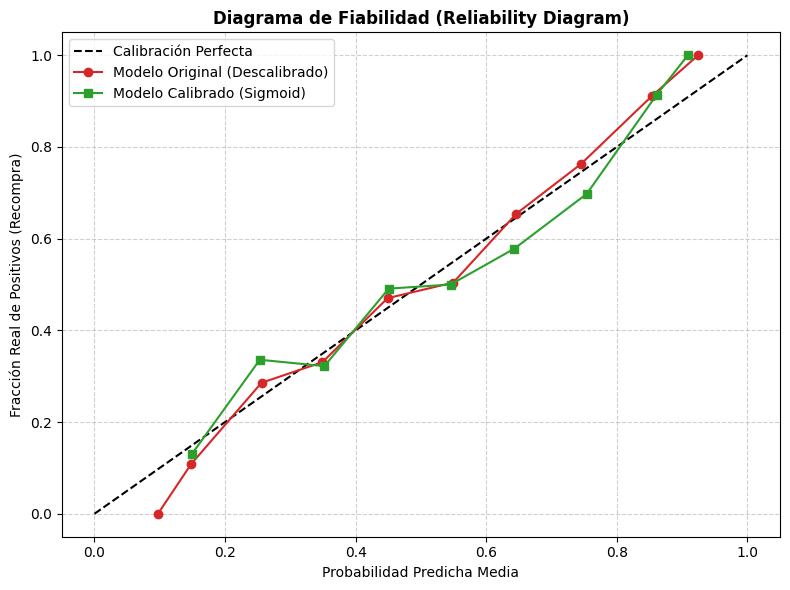

Modelo global actualizado al modelo calibrado para mxima precisin.


In [51]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
import matplotlib.pyplot as plt
import numpy as np

print("Ejecutando calibración de probabilidades sobre el modelo ganador...")

# Envolvemos el mejor modelo (ya entrenado) para calibrarlo usando validacin cruzada\n
calibrated_model = CalibratedClassifierCV(best_overall_model, method='sigmoid', cv=5)
calibrated_model.fit(X_train_scaled, y_train)

# Calculamos probabilidades antes y despus de calibrar (en test)\n
probs_uncalibrated = best_overall_model.predict_proba(X_test_scaled)[:, 1]
probs_calibrated = calibrated_model.predict_proba(X_test_scaled)[:, 1]

# Calculamos la curva de calibración real\n
prob_true_uncal, prob_pred_uncal = calibration_curve(y_test, probs_uncalibrated, n_bins=10)
prob_true_cal, prob_pred_cal = calibration_curve(y_test, probs_calibrated, n_bins=10)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot([0, 1], [0, 1], linestyle='--', color='black', label='Calibración Perfecta')
ax.plot(prob_pred_uncal, prob_true_uncal, marker='o', color='#d62728', label='Modelo Original (Descalibrado)')
ax.plot(prob_pred_cal, prob_true_cal, marker='s', color='#2ca02c', label='Modelo Calibrado (Sigmoid)')

ax.set_title("Diagrama de Fiabilidad (Reliability Diagram)", fontweight='bold')
ax.set_xlabel("Probabilidad Predicha Media")
ax.set_ylabel("Fracción Real de Positivos (Recompra)")
ax.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Actualizamos el modelo global\n
best_overall_model = calibrated_model
print("Modelo global actualizado al modelo calibrado para mxima precisin.")


**Interpretación de la Curva de Calibración:** El gráfico demuestra cómo las probabilidades brutas del modelo original (línea roja) tienden a subestimar o sobreestimar la realidad en ciertos tramos. Al aplicar *Platt Scaling* (línea verde), las probabilidades predichas se ciñen mucho más a la diagonal perfecta, asegurando que cuando el modelo emite un 80% de probabilidad de recompra, realmente 8 de cada 10 clientes de ese segmento terminen comprando. Esta calibración es vital para el cálculo exacto del ROI y del *Expected Revenue*.

### 3.5.3. Análisis del Umbral de Clasificación (Threshold de Negocio)

Por defecto, el modelo clasifica como 'recompra' (1) si la probabilidad es > 0.5. Sin embargo, en un contexto de retención, el coste de un Falso Positivo (enviar promoción a alguien que no iba a comprar) es distinto al de un Falso Negativo (no detectar a alguien que sí iba a volver).
Analicemos cómo varían Precision y Recall según el umbral.


In [52]:
print("="*75)
print("Análisis de umbrales (thresholds) para el modelo campeón ")
print("="*75)


# Obtenemos probabilidades continuas
y_probs = best_overall_model.predict_proba(X_test_scaled)[:, 1]

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
for t in thresholds:
    y_pred_t = (y_probs >= t).astype(int)
    prec = precision_score(y_test, y_pred_t)
    rec = recall_score(y_test, y_pred_t)
    f1 = f1_score(y_test, y_pred_t)
    print(f"Umbral {t:.2f} -> Precision: {prec:.3f} | Recall: {rec:.3f} | F1: {f1:.3f}")

print("\nConclusión de Negocio:")
print("Si el coste de la campaña es alto, subimos el umbral para asegurar Precision.")
print("Si retener al cliente es vital y la campaña es barata, bajamos el umbral para maximizar Recall.")

Análisis de umbrales (thresholds) para el modelo campeón 
Umbral 0.30 -> Precision: 0.640 | Recall: 0.876 | F1: 0.740
Umbral 0.40 -> Precision: 0.704 | Recall: 0.802 | F1: 0.750
Umbral 0.50 -> Precision: 0.754 | Recall: 0.696 | F1: 0.724
Umbral 0.60 -> Precision: 0.812 | Recall: 0.610 | F1: 0.697
Umbral 0.70 -> Precision: 0.875 | Recall: 0.517 | F1: 0.650

Conclusión de Negocio:
Si el coste de la campaña es alto, subimos el umbral para asegurar Precision.
Si retener al cliente es vital y la campaña es barata, bajamos el umbral para maximizar Recall.


### 3.6. Paso 6: Interpretabilidad del Modelo (Feature Importance)

**Contexto Analítico y de Negocio:**
Un modelo predictivo no debe ser una "caja negra" limitándose a escupir probabilidades. Para que el equipo de Marketing y Dirección pueda accionar los resultados, necesitan comprender cuáles son las palancas que impulsan la recompra y cuáles son los indicadores de fuga térmica.

Aprovechando la capacidad de nuestro campeón absoluto (Random Forest), procedemos a analizar la importancia de las variables. Posteriormente utilizaremos SHAP para extraer la dirección del impacto (positivo/negativo) de cada variable en la probabilidad de recompra.


Extracción de palancas de negocio (Feature Importance del Random Forest)


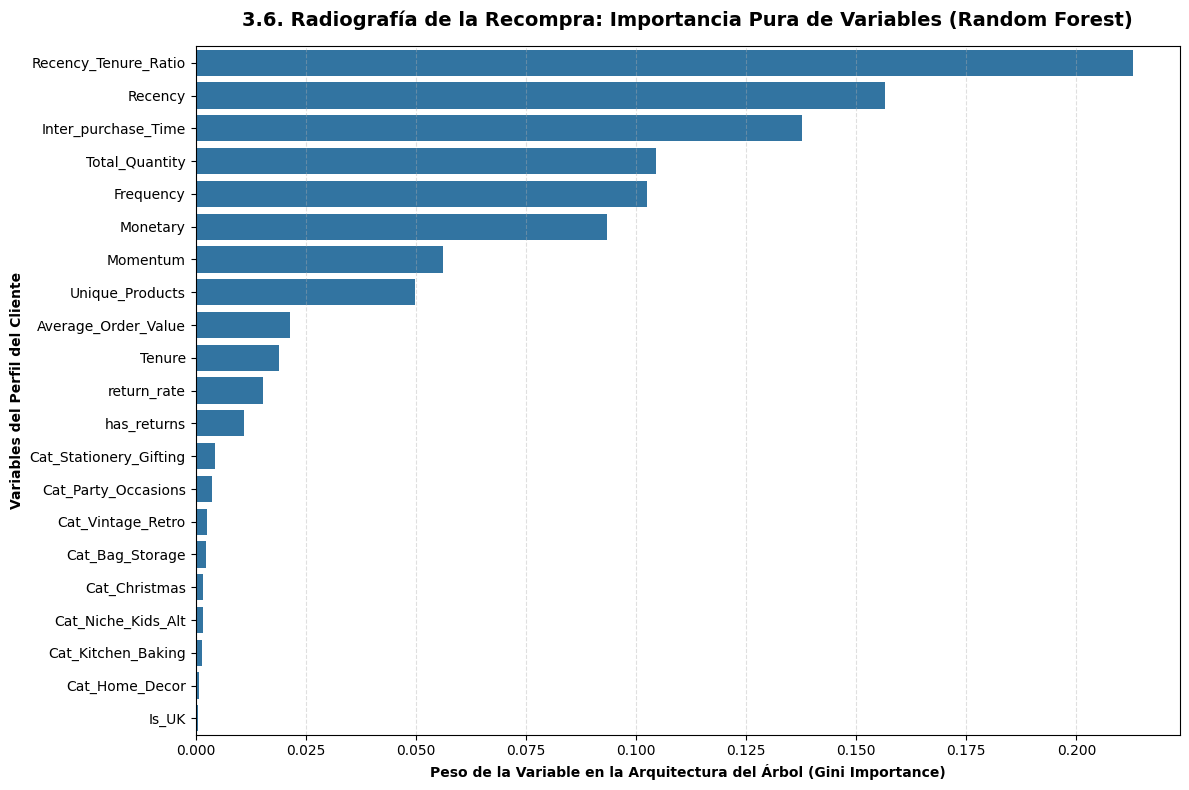


Top 3 variables más determinantes matemáticamente (Magnitud absoluta):


Palanca_de_Negocio,Importancia_Relativa
Recency_Tenure_Ratio,0.2129
Recency,0.1565
Inter_purchase_Time,0.1376


In [53]:
print("="*75)
print("Extracción de palancas de negocio (Feature Importance del Random Forest)")
print("="*75)

# 1. Rescatamos el modelo base del campeón absoluto
if hasattr(best_overall_model, 'calibrated_classifiers_'):
    rf_model = best_overall_model.calibrated_classifiers_[0].estimator
else:
    rf_model = best_overall_model

# 2. Extraemos los nombres de las columnas
features = X_train_scaled.columns

# 3. Extraemos la importancia de cada variable (Gini Importance)
importancias = rf_model.feature_importances_

# 4. Construimos un DataFrame para estructurar el impacto
df_coef = pd.DataFrame({
    'Palanca_de_Negocio': features,
    'Importancia_Relativa': importancias
})

# Ordenamos del impacto mayor al menor
df_coef = df_coef.sort_values(by='Importancia_Relativa', ascending=False)

# 5. Generando gráfico de Comité de Dirección
plt.figure(figsize=(12, 8))

# Color corporativo uniforme para magnitud (no hay positivos o negativos puros aquí)
sns.barplot(x='Importancia_Relativa', y='Palanca_de_Negocio', data=df_coef, color='#1f77b4')

# Títulos y formato estético
plt.title('3.6. Radiografía de la Recompra: Importancia Pura de Variables (Random Forest)', 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Peso de la Variable en la Arquitectura del Árbol (Gini Importance)', fontweight='bold')
plt.ylabel('Variables del Perfil del Cliente', fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

# 6. Top Insights extraídos por consola
print("\nTop 3 variables más determinantes matemáticamente (Magnitud absoluta):")
display(df_coef.head(3).style.hide(axis='index').format({"Importancia_Relativa": "{:.4f}"}))


### 3.6.1. Curva de Impacto de Negocio (Lift / Cumulative Gains)

Para traducir el rendimiento matemático en **Retorno de Inversión (ROI)**, utilizamos la curva de ganancias acumuladas. Esta gráfica responde a una necesidad directa de Marketing: *"Si solo tenemos presupuesto para contactar al 30% de nuestra base de datos, ¿a cuántos futuros recompradores capturaríamos si usamos el modelo frente a elegirlos al azar?"*.

Cuanto más se acerque la curva al vértice superior izquierdo, mayor es el "Lift" o ventaja estratégica.



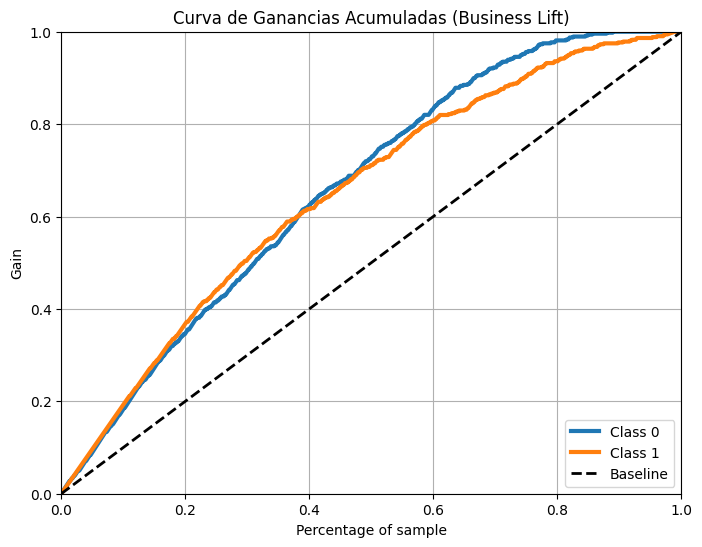

In [54]:
# Parche de compatibilidad para versiones modernas de SciPy
scipy.interp = np.interp

import matplotlib.pyplot as plt

# Extraemos las probabilidades para ambas clases en el conjunto de Test
probs_test = best_overall_model.predict_proba(X_test_scaled)

plt.figure(figsize=(8, 6))
skplt.metrics.plot_cumulative_gain(y_test, probs_test, ax=plt.gca())
plt.title("Curva de Ganancias Acumuladas (Business Lift)")
plt.show()

**Interpretación de la Curva de Ganancia Acumulada (Lift):**

El gráfico superior (Cumulative Gains) cuantifica la ventaja estratégica del modelo frente a una selección aleatoria. Si, por ejemplo, el equipo de marketing dispone de presupuesto para contactar solo al 30% de la base de clientes, la curva permite identificar qué porcentaje del total real de recompradores lograremos capturar dirigiéndonos al 30% con mayor probabilidad predictiva.

La pronunciada convexidad de la curva de la clase 1 (recompra) demuestra que el modelo es altamente eficaz concentrando a los clientes propensos en los deciles superiores, optimizando así el ROI de futuras campañas.

### 3.6.2. Interpretabilidad Avanzada (XAI) con SHAP Values

Extraer los coeficientes lineales está bien, pero para entornos de alta exigencia, utilizamos **SHAP (SHapley Additive exPlanations)**. Esta técnica basada en teoría de juegos evalúa el impacto *marginal* de cada variable en las predicciones.

El **Summary Plot** nos mostrará no solo qué variables importan, sino cómo impactan. Un punto rojo a la derecha indica que un valor alto de esa variable empuja la probabilidad de recompra hacia arriba.


Calculando valores SHAP para interpretabilidad del modelo...


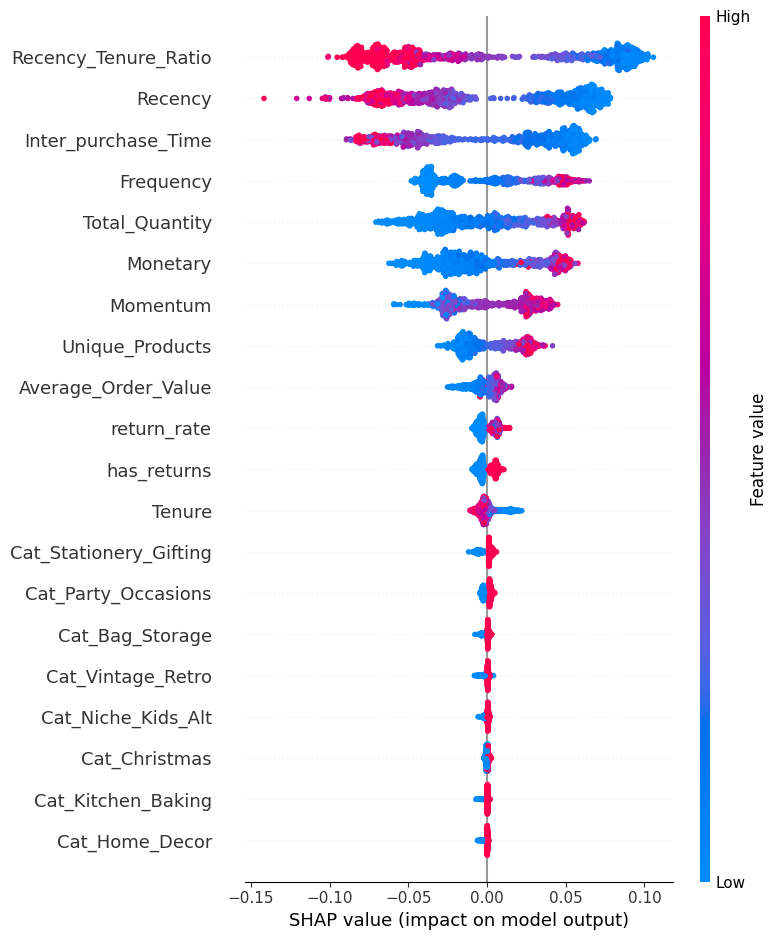

In [55]:
print("Calculando valores SHAP para interpretabilidad del modelo...")

# 1. Usamos el mejor estimador absoluto (campeón del torneo)
# NOTA: Extraemos el estimador base si está envuelto por un CalibratedClassifierCV
if hasattr(best_overall_model, 'calibrated_classifiers_'):
    modelo_explicable = best_overall_model.calibrated_classifiers_[0].estimator
else:
    modelo_explicable = best_overall_model

# 2. Convertimos a DataFrame para mantener los nombres de las variables en el gráfico
X_test_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# 3. Creamos el explicador adecuado detectando el tipo de algoritmo
if type(modelo_explicable).__name__ in ['RandomForestClassifier', 'XGBClassifier']:
    explainer = shap.TreeExplainer(modelo_explicable)
    shap_values_raw = explainer.shap_values(X_test_df)
    
    # Manejo de versiones de SHAP para Random Forest:
    # Versiones antiguas devolvían una lista de arrays. Versiones modernas (>=0.40) devuelven una matriz 3D (n_samples, n_features, n_classes).
    if isinstance(shap_values_raw, list):
        shap_values = shap_values_raw[1] # Extraemos la clase 1 (Recompra)
    elif hasattr(shap_values_raw, 'shape') and len(shap_values_raw.shape) == 3:
        shap_values = shap_values_raw[:, :, 1] # Extraemos la porción 3D de la clase 1 (Recompra)
    else:
        shap_values = shap_values_raw
else:
    explainer = shap.LinearExplainer(modelo_explicable, X_train_scaled)
    shap_values = explainer.shap_values(X_test_df)

# 4. Pintamos el Summary Plot Clásico
shap.summary_plot(shap_values, X_test_df)


### 3.6.3. Conclusiones de Negocio y Accionabilidad (Feature Importance de Random Forest)

La apertura de las métricas de importancia de nuestro **Random Forest Optimizado** (vía Feature Importance y valores SHAP) revela qué variables empujan realmente las probabilidades en los árboles de decisión. Esto nos permite pasar de la predicción algorítmica pura a la prescripción estratégica:

**Top 3 Indicadores de Riesgo (Factores de Fuga o Churn):**
1. **Ratio de Inactividad (`Recency_Tenure_Ratio` | Correlación Negativa):** 
   Es el predictor más dominante y crítico del modelo. Representa la proporción del "ciclo de vida" de un cliente que este ha pasado inactivo. Si esta proporción crece, la probabilidad matemática de recuperar al cliente se hunde de inmediato.
2. **Ciclos Largos (`Inter_purchase_Time` | Correlación Negativa):** 
   Clientes con una gran separación en días entre un pedido y el siguiente (cadencia lenta) tienen una propensión orgánica bajísima a realizar nuevas recompras a corto plazo. 
3. **Enfriamiento Directo (`Recency` | Correlación Negativa):** 
   Independientemente de la antigüedad, cada día transcurrido desde la última transacción erosiona el vínculo entre la marca y el consumidor. **Acción:** Los impactos de reactivación (emails, SMS) deben ocurrir en las fases iniciales de latencia.

**Top 3 Palancas de Retención (Factores de Retención Positivos):**
1. **El Hábito como Rey (`Frequency` | Correlación Positiva):** 
   Como demuestra contundentemente el gráfico (concentración de puntos rojos en el lado derecho), la frecuencia de compra es el predictor de lealtad más potente. Fomentar visitas recurrentes genera más valor y anclaje a largo plazo que intentar forzar el volumen de una sola compra.
2. **Valor Bruto Acumulado (`Monetary` | Correlación Positiva):** 
   El historial de gasto sigue siendo un motor clásico de fidelización. Aquellos clientes que ya han invertido un gran capital en la empresa tienen barreras psicológicas de salida mucho más altas. El modelo detecta que esta inversión económica ancla firmemente al cliente y reduce drásticamente el riesgo de fuga.
3. **Volumen Físico (`Total_Quantity` | Correlación Positiva):** 
   Los clientes que adquieren un alto volumen de artículos físicos también exhiben una clara inercia a volver a comprar, aunque su peso es secundario frente a la frecuencia. **Acción:** Promover campañas de *upselling* y *bundles* (packs de descuento por volumen) para incentivar el tamaño de las cestas.

**Recomendación Estratégica:** El equipo de Marketing debe pivotar de una estrategia genérica a disparar campañas quirúrgicas automatizadas tan pronto como la métrica de *Recency_Tenure_Ratio* supere los márgenes de seguridad identificados por el Random Forest.


### 3.7. Paso 7: Serialización y Exportación a Producción (MLOps)

**Contexto Técnico:**
El ciclo de vida del modelo predictivo dentro del entorno de experimentación (Jupyter Notebook) ha concluido. Para que este activo analítico genere valor de negocio, debe ser integrado en la arquitectura de software de la compañía (ej. un microservicio web, un pipeline de datos diario o un CRM).

Este proceso de transición se conoce como serialización. Convertiremos nuestros objetos matemáticos de la memoria RAM en archivos físicos binarios (`.pkl` o `.joblib`) que los Ingenieros de Datos o de Machine Learning (MLOps) puedan cargar en los servidores de producción.

**Elementos a Exportar (El Pipeline de Inferencia):**
1. **El Preprocesador (`scaler.joblib`):** Es de vital importancia exportar el `StandardScaler` ajustado en el Paso 2. Cualquier dato futuro de un cliente nuevo debe ser transformado utilizando la misma media y varianza que el modelo aprendió durante su entrenamiento para evitar colapsos matemáticos en la inferencia.
2. **El Algoritmo Campeón (`modelo_recompra_rf.joblib`):** El Random Forest Optimizado y calibrado, con todos sus árboles de decisión y parámetros bloqueados, listo para emitir probabilidades reales de recompra en nuevos clientes.


In [56]:
import joblib
import os
print("="*75)
print("Preparación de entregables para producción (mlops)")
print("="*75)

# 1. Creamos un directorio específico para guardar los artefactos si no existe
directorio_salida = 'modelos_produccion'
if not os.path.exists(directorio_salida):
    os.makedirs(directorio_salida)
    print(f"[*] Directorio '{directorio_salida}' creado con éxito.")

# 2. Definimos las rutas de los archivos
ruta_modelo = os.path.join(directorio_salida, 'modelo_recompra_rf.joblib')
ruta_escalador = os.path.join(directorio_salida, 'scaler_rfm.joblib')

# 3. Exportación del Modelo Campeón (Random Forest Optimizado)
# best_overall_model contiene el modelo final que determinamos en GridSearchCV
joblib.dump(best_overall_model, ruta_modelo)
print(f"[+] Modelo predictivo exportado correctamente: {ruta_modelo}")

# 4. Exportación del Preprocesador (El StandardScaler del Paso 2)
joblib.dump(scaler, ruta_escalador)
print(f"[+] Escalador matemático exportado correctamente: {ruta_escalador}")

# 5. Verificación de tamaño de archivos para auditoría
size_modelo = os.path.getsize(ruta_modelo) / 1024 # en KB
size_escalador = os.path.getsize(ruta_escalador) / 1024 # en KB

print("-" * 75)
print("Resumen de artefactos:")
print(f" -> Modelo: {size_modelo:.2f} KB")
print(f" -> Escalador: {size_escalador:.2f} KB")
print("="*75)
print("¡Proyecto finalizado y listo para deployment!")


Preparación de entregables para producción (mlops)
[+] Modelo predictivo exportado correctamente: modelos_produccion\modelo_recompra_rf.joblib
[+] Escalador matemático exportado correctamente: modelos_produccion\scaler_rfm.joblib
---------------------------------------------------------------------------
Resumen de artefactos:
 -> Modelo: 6008.49 KB
 -> Escalador: 1.22 KB
¡Proyecto finalizado y listo para deployment!


## 4. Entregable de Negocio: Predicción y Segmentación

El objetivo final del modelo no es solo evaluar métricas, sino generar un output accionable para el equipo de Marketing o CRM. A continuación generamos la lista de todos los clientes con su probabilidad de recompra y su segmento de propensión.


> **Nota Estratégica sobre los Umbrales:** Basándonos en el análisis exhaustivo de la curva Precisión-Recall (Sección 3.5.3), hemos establecido los puntos de corte en **0.70** (para garantizar una altísima precisión y evitar gasto inútil en acciones VIP caras) y **0.40** (para maximizar el alcance en acciones de reactivación de bajo coste).


In [57]:
print("Generando entregable de negocio...")

# 1. Usaremos df_model original o asumiendo que lo tenemos cargado en memoria
if 'Customer ID' in df_model.columns:
    # Preparamos las features (aplicamos el scaler ya entrenado)
    X_full = df_model.drop(columns=['Customer ID', 'Target'])
    X_full_scaled = X_full.copy()
    continuas = [col for col in X_full.columns if X_full[col].nunique() > 2]
    X_full_scaled[continuas] = scaler.transform(X_full[continuas])
    
    # Predecimos probabilidad sobre todo el universo de clientes
    probs_full = best_overall_model.predict_proba(X_full_scaled)[:, 1]
    
    # 2. Creamos DataFrame final
    df_business = pd.DataFrame({
        'Customer ID': df_model['Customer ID'],
        'Probabilidad_Recompra': probs_full
    })
    
    # --- NUEVO: EXPECTED REVENUE ---
    # Inyectamos el Ticket Medio (AOV) desde df_model
    df_business = df_business.merge(df_model[['Customer ID', 'Average_Order_Value']], on='Customer ID', how='left')
    
    # Calculamos el Dinero Esperado = Probabilidad * Gasto Medio
    df_business['Expected_Revenue'] = df_business['Probabilidad_Recompra'] * df_business['Average_Order_Value']
    
    # 3. Segmentación por cuartiles o umbrales duros
    # Vectorizacin con np.select para mxima eficiencia
    condiciones = [
        df_business['Probabilidad_Recompra'] >= 0.70,
        df_business['Probabilidad_Recompra'] >= 0.40
    ]
    etiquetas = ['Alta Probabilidad', 'Dudoso (Incentivar)']
    df_business['Segmento_CRM'] = np.select(condiciones, etiquetas, default='Riesgo de Fuga')
    
    # 4. Ordenamos para entregar al negocio (los de mayor propensión primero)
    df_business = df_business.sort_values(by='Expected_Revenue', ascending=False)
    
    # 5. Exportamos a CSV
    business_path = '../data/processed/predicciones_clientes_recompra.csv'
    df_business.to_csv(business_path, index=False)
    
    
    print(f"ENTREGABLE GENERADO: {business_path}")
    
    print("Muestra del entregable para CRM:")
    display(df_business.head(10))
else:
    print("No se encontró 'Customer ID' en memoria para generar el entregable.")


Generando entregable de negocio...
ENTREGABLE GENERADO: ../data/processed/predicciones_clientes_recompra.csv
Muestra del entregable para CRM:


,Customer ID,Probabilidad_Recompra,Average_Order_Value,Expected_Revenue,Segmento_CRM
4358,15749,0.692077,8264.865133,5719.925597,Dudoso (Incentivar)
3757,14088,0.900355,4132.432567,3720.657034,Alta Probabilidad
3508,13687,0.304294,11880.840000,3615.271945,Riesgo de Fuga
4105,12357,0.575460,6039.995000,3475.775227,Dudoso (Incentivar)
4877,12590,0.664985,4932.130000,3279.791763,Dudoso (Incentivar)
4314,12753,0.825455,3235.127500,2670.453071,Alta Probabilidad
2644,18052,0.206114,10877.180000,2241.934822,Riesgo de Fuga
2069,12477,0.868447,2326.720000,2020.633871,Alta Probabilidad
1639,13340,0.795081,2507.018333,1993.282617,Alta Probabilidad
216,17940,0.842396,2254.054127,1898.805894,Alta Probabilidad
